#3-DOF Rocket Model

Síntese de Sistema de Controle para Modelo de 3DOF de Foguete

Modelagem de foguete de foguetemodelismo em 3 graus de liberdade, sob o objetivo de controlar a atitude e altitude do foguete por meio de entradas de controle de empuxo, sob o objetivo de desenvolver um protótipo de Self Landing Rocket.

Entradas de Controle - $T$ (Empuxo Central do Foguete)  e $T_{lat}$ (Empuxo Lateral do Foguete)

Entrada de Perturbação - $w$ (Vento Horizontal)


### Instalação dos Pacotes Necessários

In [721]:
#%pip install numpy
#%pip install scipy
#%pip install sympy
%pip install tbcontrol
#%pip install seaborn
%pip install control


import numpy as np
from scipy.integrate import solve_ivp
import sympy as sp
from sympy.abc import s
from sympy.physics.control.lti import TransferFunction
import control as ct
from tbcontrol.symbolic import routh
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from seaborn import color_palette
colors = color_palette()

In [722]:
from sympy.physics.control.control_plots import pole_zero_plot

## Definição do Modelo

### Modelagem matemática - equação de movimento do veículo

Equacionamento físico do sistema utilizando o Teorema da Resultante e o TQMA, baseando-se no método de Newton-Euler

Definição de variáveis e funções simbólicas (pacote `sympy`):

In [723]:

m, g, Jg, ρ, A_m, A_f, Cl, D_Cp, α, φ, D_n, β = sp.symbols(
    'm, g, Jg, ρ, A_m, A_f, Cl, D_Cp, α, φ, D_n, β', positive=True)
t = sp.symbols('t')
w = sp.symbols('w')
θ = sp.Function('θ')(t)
x = sp.Function('x')(t)
y = sp.Function('y')(t)
Cd = sp.Function('Cd')(t)
T = sp.Function('T')(t)
s = sp.symbols('s')
T_lat = sp.Function('T_lat')(t)

Cinemática - Velocidade Relativa ao Vento

In [724]:
vx_vento = x.diff(t) - w
vy_vento = y.diff(t)
print(vx_vento)
print(vy_vento)

-w + Derivative(x(t), t)
Derivative(y(t), t)


Ângulo de Velocidade Relativa ($φ$) e de Ataque ($α$)

In [725]:
φ = sp.pi/2 - sp.atan(vx_vento/vy_vento)
α = φ - θ

Força de Arrasto

In [726]:
D = Cd * sp.Rational(1, 2)* ρ * A_f * (vx_vento**2 + vy_vento**2)
D

A_f*ρ*((-w + Derivative(x(t), t))**2 + Derivative(y(t), t)**2)*Cd(t)/2

Força de Sustentação

In [727]:
L = Cl * sp.Rational(1, 2)* ρ * A_m * (vx_vento**2 + vy_vento**2) * sp.sin(α)
L

A_m*Cl*ρ*((-w + Derivative(x(t), t))**2 + Derivative(y(t), t)**2)*cos(θ(t) + atan((-w + Derivative(x(t), t))/Derivative(y(t), t)))/2

#### Equações Diferenciais Governantes

$T$: Entrada de Controle: Empuxo Central do Foguete, provido por motor híbrido/líquido com devida regulação de injeção

$T_{lat}$: Entrada de Controle: Empuxo Lateral do Foguete, provido por Cold Gas Thruster (Semelhante ao sistema de nitrogênio presente no Falcon 9 da SpaceX)

$θ$: Ângulo de arfagem do foguete

$D_{Cp}$: Distância entre CM e CP

$D_n$: Distância entre CM e Propulsores Laterais

In [728]:
from operator import eq
eqx = m*x.diff(t, 2) + L*sp.cos(φ+sp.pi/2) + D*sp.cos(φ) - T_lat*sp.cos(θ + sp.pi/2) - T*sp.cos(θ)
eqy = m*y.diff(t, 2) + L*sp.sin(φ+sp.pi/2) + D*sp.sin(φ) + m*g - T_lat*sp.sin(θ + sp.pi/2)  - T*sp.sin(θ)
eqθ = Jg*θ.diff(t, 2) - L*D_Cp*sp.sin(α+sp.pi/2) + D*D_Cp*sp.sin(α) - T_lat*D_n


In [729]:
d2x_s = sp.solve(eqx, x.diff(t, 2))[0]
d2x_s = d2x_s.subs({ρ: 1.225 * (1 - 2.25577e-5 * y)**4.2561}).simplify() #Modelo de atmosfera ISA aplicado

In [730]:
d2y_s = sp.solve(eqy, y.diff(t, 2))[0]
d2y_s = d2y_s.subs({ρ:1.225 * (1 - 2.25577e-5 * y)**4.2561}).simplify()

In [731]:
d2θ_s = sp.solve(eqθ, θ.diff(t, 2))[0]
d2θ_s = d2θ_s.subs({ρ: 1.225 * (1 - 2.25577e-5 * y)**4.2561}).simplify()

### Linearização do Modelo

Imposição da Condição de Equilíbrio (Voo Vertical com Aceleração e Velocidade vertical em regime controlado) e dados dinâmicos do foguete Odisseia II, para conhecimento de Empuxo de equilíbrio


In [732]:
# Define velocidade de interesse para linearização
V0 = 100  # Velocidade de interesse (m/s)

In [733]:
eqxs = eqx.subs({ θ: sp.pi/2, β: 0, x.diff(t): 0,y.diff(t): V0,  θ.diff(t): 0,x.diff(t,2): 0,  Cd: 0.35, w: 0, m: 27, Jg: 12.622, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 }) #T: 558.26,
eqys = eqy.subs({ θ: sp.pi/2, β: 0, x.diff(t): 0,y.diff(t): V0,  θ.diff(t): 0,x.diff(t,2): 0,  Cd: 0.35, w: 0, m: 27, Jg: 12.622, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })
eqθs = eqθ.subs({ D_n: 1, θ:sp.pi/2, β: 0, x.diff(t): 0,y.diff(t): V0,  θ.diff(t): 0,   Cd: 0.35, w: 0, m: 27, Jg: 12.622, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })


In [734]:
T_lateq = sp.solve(eqxs, T_lat) #Calculo do T_lat para o equilíbrio em x
T_eq = sp.solve(eqys, T) #Calculo do T para o equilíbrio em y
print("Empuxo Central (T_eq): ", T_eq)
print("Empuxo Lateral (T_lat): ", T_lateq)

Empuxo Central (T_eq):  [309.888750000000]
Empuxo Lateral (T_lat):  [0]


Equações de movimento linearizadas, em termos das variáveis de estado incrementais $\mathbf{x} = (y, \theta,\dot x, \dot y, \dot \theta)$, expressa na forma de espaço de estados com as entradas $dT, dT_{lat}, dw$ representando variações incrementais ao redor da condição de equilíbrio:
$\dfrac{\text{d} \mathbf{x}}{\text{d} t} = \mathbf{A} \mathbf{x} + \mathbf{B_1} \mathbf{u_1} + \mathbf{B_2} \mathbf{u_2} + \mathbf{E} \mathbf{w}$

Foram utilizadas as condições de equilíbrio definidas anteriormente, caracterizando uma linearização ao redor de uma trajetória, o que gera um sistema linear com dependência no tempo.

In [735]:
dxdt = sp.Matrix([ y.diff(t), θ.diff(t), d2x_s, d2y_s, d2θ_s])
dxdt

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             Derivative(y(t), t)],
[                                                                                                                                                                                                                                                          

In [736]:
At = dxdt.jacobian(([y, θ, x.diff(t), y.diff(t), θ.diff(t)])).subs({y: 0 + V0*t, T: T_eq[0], θ: sp.pi/2, D_n: 1, T_lat: 0, β: 0, x.diff(t): 0, y.diff(t):  V0, Cd: 0.35, w: 0, m: 27, Jg: 12.622, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })
At

Matrix([
[                                              0,                                                               0,                                              0,                                              1, 0],
[                                              0,                                                               0,                                              0,                                              0, 1],
[                                              0, -7.14583333333333*(1 - 0.00225577*t)**4.2561 - 11.4773611111111, -0.0881319444444445*(1 - 0.00225577*t)**4.2561,                                              0, 0],
[0.000160079717052063*(1 - 0.00225577*t)**3.2561,                                                               0,                                              0, -0.0333472222222222*(1 - 0.00225577*t)**4.2561, 0],
[                                              0,                    -4.46498524401838*(1 - 0.00225577*t)**4.2561, -0.0446498524401

In [737]:
B1 = dxdt.diff(T).subs({y: 0 + V0*t, T: T_eq[0], θ: sp.pi/2, D_n: 1, T_lat: 0, β: 0, x.diff(t): 0, y.diff(t): 100, Cd: 0.35, w: 0, m: 27, Jg: 12.622, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })
B1

Matrix([
[   0],
[   0],
[   0],
[1/27],
[   0]])

In [738]:
B2 = dxdt.diff(T_lat).subs({y: 0 + V0*t, T: T_eq[0], θ: sp.pi/2, D_n: 1, T_lat: 0, β: 0, x.diff(t): 0, y.diff(t): 100, Cd: 0.35, w: 0, m: 27, Jg: 12.622, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })
B2

Matrix([
[                 0],
[                 0],
[             -1/27],
[                 0],
[0.0792267469497702]])

In [739]:
Et = dxdt.diff(w).subs({y: 0 + V0*t, T: T_eq[0], θ: sp.pi/2, D_n: 1, T_lat: 0, β: 0, x.diff(t): 0, y.diff(t): 100, Cd: 0.35, w: 0, m: 27, Jg: 12.622, A_f: 0.021, A_m: 0.021, g: 9.81, ρ: 1.225, D_Cp: 0.381, Cl: 1.5 })
Et

Matrix([
[                                            0],
[                                            0],
[0.0881319444444445*(1 - 0.00225577*t)**4.2561],
[                                            0],
[0.0446498524401838*(1 - 0.00225577*t)**4.2561]])

Verificada baixa dependência no tempo, será considerado sistema SLIT para o tempo intermediário de um horizonte de voo de 30 segundos

In [740]:
A = At.subs({t: 15})
E = Et.subs({t: 15})
A

Matrix([
[                   0,                 0,                   0,                   1, 0],
[                   0,                 0,                   0,                   0, 1],
[                   0, -17.6493730675908, -0.0761214807965823,                   0, 0],
[0.000143106572420408,                 0,                   0, -0.0288027224635717, 0],
[                   0, -3.85650504651941, -0.0385650504651942,                   0, 0]])

### Criação do Espaço de Estados na Biblioteca Control

Aqui foi definido o vetor de observações do sistema como sendo respectivamente, a observação da altitude do veículo e sua atitude em relação à horizontal. Também foram unidos as duas entradas de controle em vetor único para posterior uso da biblioteca _Control_

In [741]:
O1 = sp.Matrix([[1],[0],[0],[0],[0]])
O2 = sp.Matrix([[0],[1],[0],[0],[0]])
O = sp.Matrix.hstack(O1, O2)
B = sp.Matrix.hstack(B1, B2)

Para permitir a análise direta do sistema foram definidas as matrizes A e E de estado inicial, permitindo avaliar o sistema como SLIT, no instante inicial

In [742]:
Rocket = ct.ss(A, B, O.transpose(), sp.zeros(2, 2))
print(Rocket)

<StateSpace>: sys[177]
Inputs (2): ['u[0]', 'u[1]']
Outputs (2): ['y[0]', 'y[1]']
States (5): ['x[0]', 'x[1]', 'x[2]', 'x[3]', 'x[4]']

A = [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
       0.00000000e+00]
     [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
       1.00000000e+00]
     [ 0.00000000e+00 -1.76493731e+01 -7.61214808e-02  0.00000000e+00
       0.00000000e+00]
     [ 1.43106572e-04  0.00000000e+00  0.00000000e+00 -2.88027225e-02
       0.00000000e+00]
     [ 0.00000000e+00 -3.85650505e+00 -3.85650505e-02  0.00000000e+00
       0.00000000e+00]]

B = [[ 0.          0.        ]
     [ 0.          0.        ]
     [ 0.         -0.03703704]
     [ 0.03703704  0.        ]
     [ 0.          0.07922675]]

C = [[1. 0. 0. 0. 0.]
     [0. 1. 0. 0. 0.]]

D = [[0. 0.]
     [0. 0.]]


In [743]:
Rocket_Pert = ct.ss(A, E, O.transpose(), sp.zeros(2, 1))
print(Rocket_Pert)

<StateSpace>: sys[178]
Inputs (1): ['u[0]']
Outputs (2): ['y[0]', 'y[1]']
States (5): ['x[0]', 'x[1]', 'x[2]', 'x[3]', 'x[4]']

A = [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
       0.00000000e+00]
     [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
       1.00000000e+00]
     [ 0.00000000e+00 -1.76493731e+01 -7.61214808e-02  0.00000000e+00
       0.00000000e+00]
     [ 1.43106572e-04  0.00000000e+00  0.00000000e+00 -2.88027225e-02
       0.00000000e+00]
     [ 0.00000000e+00 -3.85650505e+00 -3.85650505e-02  0.00000000e+00
       0.00000000e+00]]

B = [[0.        ]
     [0.        ]
     [0.07612148]
     [0.        ]
     [0.03856505]]

C = [[1. 0. 0. 0. 0.]
     [0. 1. 0. 0. 0.]]

D = [[0.]
     [0.]]


## Funções de Transferência do Sistema
Desenvolvimento dos Equacionamentos Necessários para definir as funções de transferência para as entradas $T, T_{lat}, w$, para os vetores os vetores de observação $o(t) = θ(t)$ e $o(t) = y(t)$ obtendo:

$G1 = T(s)/T(s)$

$G2 = Θ(s)/T_{lat}(s)$

$G3 = Θ(s)/W(s)$

In [744]:
G1frac = sp.fraction((O1.transpose() * (s*sp.eye(5) - A).inv() * B1)[0].simplify())
G2frac = sp.fraction((O2.transpose() * (s*sp.eye(5) - A).inv() * B2)[0].simplify())
G3frac = sp.fraction((O2.transpose() * (s*sp.eye(5) - A).inv() * E)[0].simplify())
G1 = TransferFunction(G1frac[0], G1frac[1], s)
G2 = TransferFunction(G2frac[0], G2frac[1], s)
G3 = TransferFunction(G3frac[0], G3frac[1], s)

In [745]:
print("Função de Transferência do Controle de Altitude (G1):")
G1.simplify()

Função de Transferência do Controle de Altitude (G1):


TransferFunction(1.0*s**3 + 0.0761214807965823*s**2 + 3.85650504651941*s - 0.387086088190126, 27.0*s**5 + 2.83295348802416*s**4 + 104.180970037461*s**3 - 7.45251670278183*s**2 - 0.315927658432239*s + 0.00149565320943784, s)

In [746]:
print("Função de Transferência do Controle de Atitude (G2):")
G2.simplify()

Função de Transferência do Controle de Atitude (G2):


TransferFunction(2.1391221676438*s**8 + 0.487456428697512*s**7 + 8.28701023638399*s**6 + 0.424950308541541*s**5 - 0.0764273663598444*s**4 - 0.00458684898414727*s**3 - 4.1768923239545e-5*s**2 + 6.41616142937073e-7*s - 1.59654918456184e-9, 27.0*s**10 + 5.66590697604832*s**9 + 208.659185462526*s**8 + 6.95717714653752*s**7 + 399.792191037616*s**6 - 57.5751885215894*s**5 - 0.380697051743462*s**4 + 0.185946278039696*s**3 + 0.00287101941898771*s**2 - 3.50013493543971e-5*s + 8.28510564037672e-8, s)

In [747]:
print("Função de Transferência da Altitude e Atitude à Perturbação (G3):")
G3.simplify()

Função de Transferência da Altitude e Atitude à Perturbação (G3):


TransferFunction(0.0385650504651942*s**3 + 0.00111077844534262*s**2 - 5.51891218729401e-6*s - 5.29395592033938e-23, 1.0*s**5 + 0.104924203260154*s**4 + 3.85855444583189*s**3 - 0.276019137140068*s**2 - 0.0117010243863792*s + 5.53945633125126e-5, s)

In [748]:
def poly_to_coeffs(poly_expr, symbol):
    poly = sp.poly(poly_expr, symbol)
    coeffs = poly.all_coeffs()
    return [float(c) for c in coeffs]

## Análise de estabilidade do modelo linearizado

A análise baseada na verificação da posição dos polos do sistema indica instabilidade inerente do sistema, devido a presença de polos com parte real negativa. Tais instabilidades estão presentes nos polos relativos a posição vertical e ao angulo de atitude do foguete, com este último possuindo forte dependência da velocidade $y$ do foguete, uma vez que o controle passivo de atitude via momento restaurador das aletas depende do valor da força de lift.

In [749]:
Rocket.poles()

array([ 0.00432044+0.j        , -0.03312316+0.j        ,
        0.09991654+0.j        , -0.08801901+1.96630283j,
       -0.08801901-1.96630283j])

Polinômio característico da matriz ${A}$:

In [750]:
p = A.charpoly('s')
p

PurePoly(1.0*s**5 + 0.104924203260154*s**4 + 3.85855444583189*s**3 - 0.276019137140068*s**2 - 0.0117010243863792*s + 5.53945633125126e-5, s, domain='RR')

Tabela de Routh do polinômio caracterísitico:

In [751]:
RH_t =routh(p)
RH_t

Matrix([
[                1.0,    3.85855444583189, -0.0117010243863792],
[  0.104924203260154,  -0.276019137140068, 5.53945633125126e-5],
[   6.48920713190179, -0.0122289727680807,                   0],
[ -0.275821406477708, 5.53945633125126e-5,                   0],
[-0.0109257135326696,                   0,                   0],
[5.53945633125126e-5,                   0,                   0]])

In [752]:
sp.solve(p, s)

[-0.0331231607646510,
 0.00432043830107938,
 0.0999165411384466,
 -0.0880190109675145 - 1.96630282776797*I,
 -0.0880190109675145 + 1.96630282776797*I]

### Polos e Zeros via Control

<TransferFunction>: sys[181]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

           0.03704
  --------------------------
  s^2 + 0.0288 s - 0.0001431


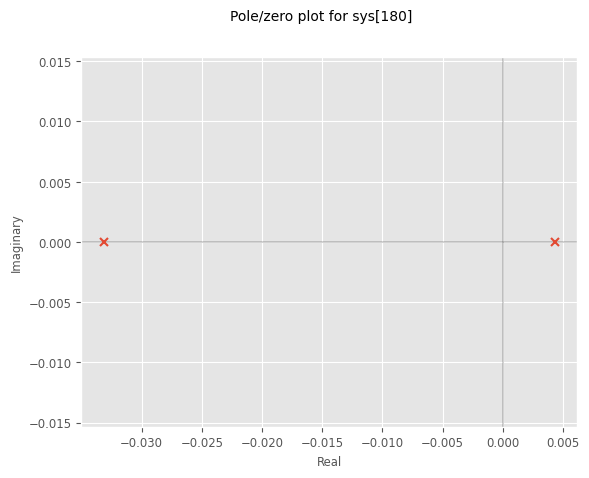

In [753]:
T1 = ct.tf(poly_to_coeffs(G1frac[0], s), poly_to_coeffs(G1frac[1], s)).minreal()
ct.pole_zero_plot(T1)
print(T1.minreal())

<TransferFunction>: sys[184]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          0.07923 s + 0.007459
  ------------------------------------
  s^3 + 0.07612 s^2 + 3.857 s - 0.3871


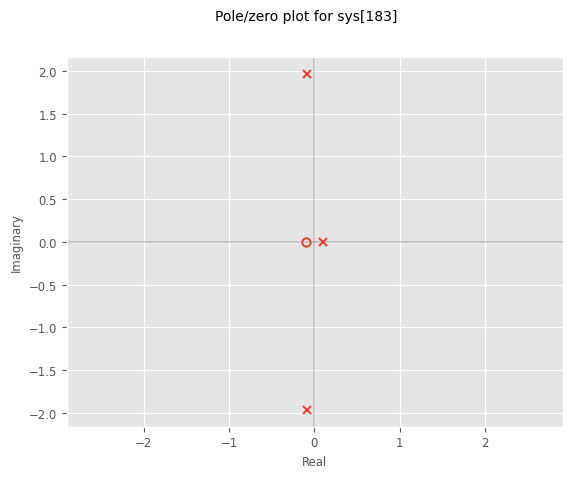

In [754]:
T2 = ct.tf(poly_to_coeffs(G2frac[0], s), poly_to_coeffs(G2frac[1], s)).minreal()
ct.pole_zero_plot(T2)
print(T2.minreal())

<TransferFunction>: sys[187]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         0.03857 s + 3.699e-19
  ------------------------------------
  s^3 + 0.07612 s^2 + 3.857 s - 0.3871


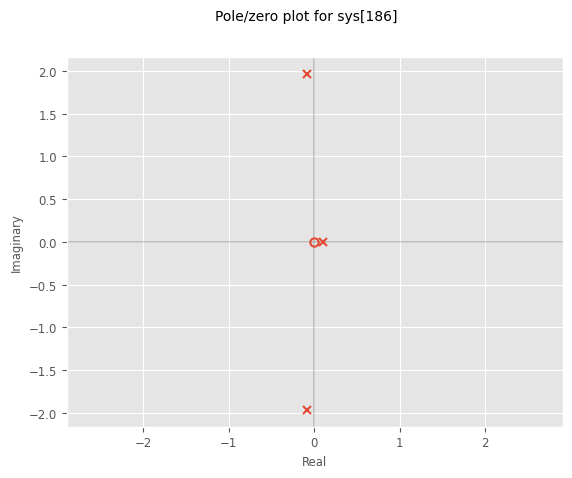

In [755]:
T3 = ct.tf(poly_to_coeffs(G3frac[0], s), poly_to_coeffs(G3frac[1], s)).minreal()
ct.pole_zero_plot(T3)
print(T3.minreal())

## Análise no Domínio da Frequência
Desenvolvimento e análise dos Diagramas de Bode do Sistema

/usr/local/lib/python3.12/dist-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


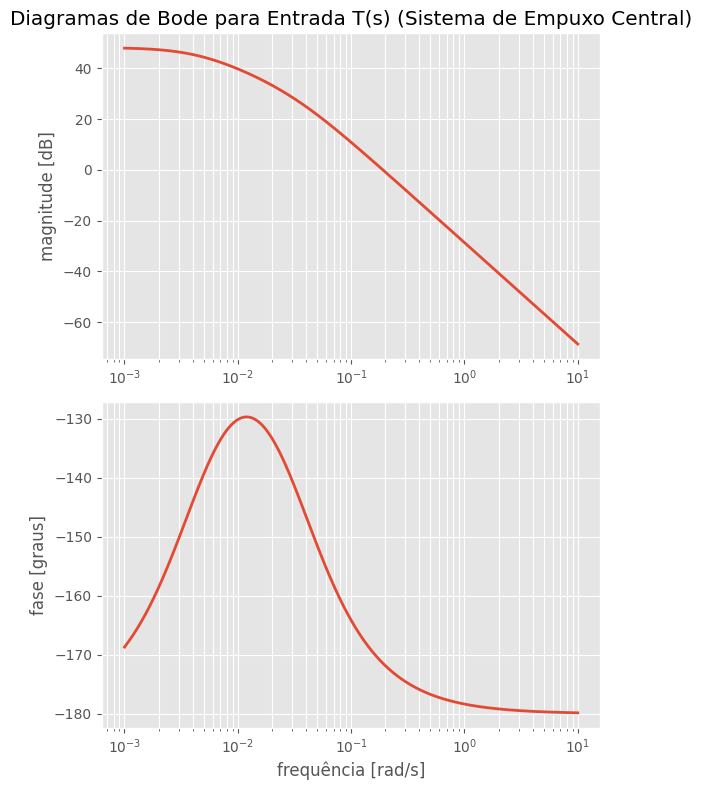

In [756]:
plt.figure(figsize=(6, 8))

mag, phase, omega = ct.bode(T1, omega_limits=(0.001, 10), plot=False)

plt.subplot(2, 1, 1)
plt.title("Diagramas de Bode para Entrada T(s) (Sistema de Empuxo Central)")
plt.semilogx(omega, 20 * np.log10(mag), linewidth=2)
plt.ylabel("magnitude [dB]")
plt.grid(True, which="both")

plt.subplot(2, 1, 2)
plt.semilogx(omega, np.rad2deg(phase), linewidth=2)
plt.ylabel("fase [graus]")
plt.xlabel("frequência [rad/s]")
plt.grid(True, which="both")

plt.tight_layout()
plt.show()


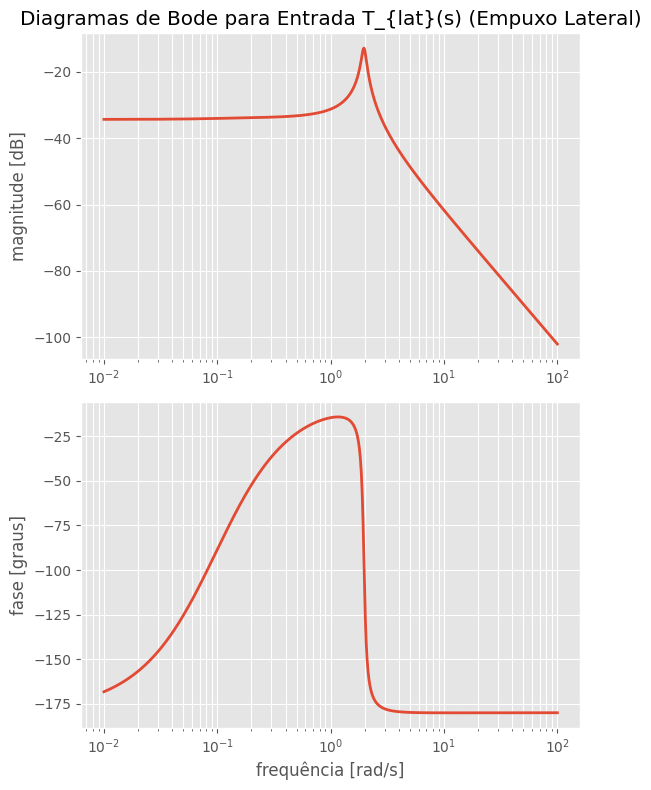

In [757]:
plt.figure(figsize=(6, 8))

mag1, phase1, omega1 = ct.bode(T2, omega_limits=(0.01, 100), plot=False)

plt.subplot(2, 1, 1)
plt.title("Diagramas de Bode para Entrada T_{lat}(s) (Empuxo Lateral)")
plt.semilogx(omega1, 20 * np.log10(mag1), linewidth=2)
plt.ylabel("magnitude [dB]")
plt.grid(True, which="both")

plt.subplot(2, 1, 2)
plt.semilogx(omega1, np.rad2deg(phase1), linewidth=2)
plt.ylabel("fase [graus]")
plt.xlabel("frequência [rad/s]")
plt.grid(True, which="both")

plt.tight_layout()
plt.show()

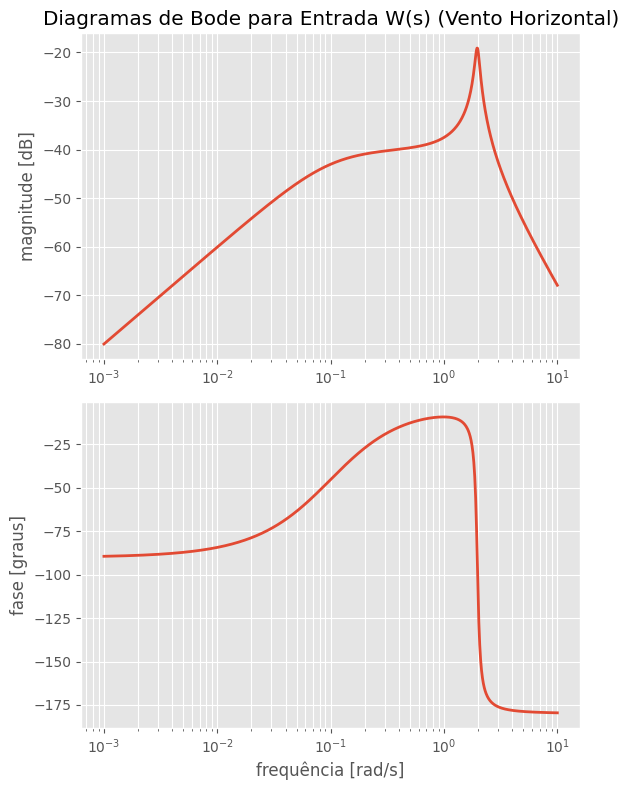

In [758]:
plt.figure(figsize=(6, 8))

mag, phase, omega = ct.bode(T3, omega_limits=(0.001, 10), plot=False)

plt.subplot(2, 1, 1)
plt.title("Diagramas de Bode para Entrada W(s) (Vento Horizontal)")
plt.semilogx(omega, 20 * np.log10(mag), linewidth=2)
plt.ylabel("magnitude [dB]")
plt.grid(True, which="both")

plt.subplot(2, 1, 2)
plt.semilogx(omega, np.rad2deg(phase), linewidth=2)
plt.ylabel("fase [graus]")
plt.xlabel("frequência [rad/s]")
plt.grid(True, which="both")

plt.tight_layout()
plt.show()

O diagrama de Bode para a entrada $T(s)$ e saída $y(s)$ indica comportamento característico de primeira ordem, o que é esperado para uma entrada do tipo força e saída posicional, considerando o efeito integrador dessa variável com ganhos elevados em baixas frequências e baixo ganho para altas frequências.

O segundo diagrama, relativo a entrada $T_{lat}(s)$ e saída $Θ(s)$, apresenta comportamento clássico de segunda ordem, o que é esperado para uma saída angular à uma entrada de força, considerando principalmente frequências naturais que podem ser excitadas. Além disso, destaca-se que o amortecimento do sistema é dependente da velocidade à qual o sistema é linearizado.

Em altas frequências $\frac{Θ(s)}{E(s)}$ apresentou um comportamento de segunda ordem, esperado pelo fato de, próximo a frequência natural, a velocidade do vento promove grandes oscilações do foguete ao redor de seu eixo, devido a um grande acoplamento de equacionamentos.

## Análise No Tempo Para Entradas Padrão

Resposta no Tempo para entradas Padrão para $G_1(s)$

In [759]:
stepG1 = ct.step_response(T1, np.linspace(0, 30, 5000))
impulseG1 = ct.impulse_response(T1, np.linspace(0, 30, 5000))
time_vector = np.linspace(0, 30, 5000)
ramp_input = time_vector
rampG1 = ct.forced_response(T1, time_vector, ramp_input)

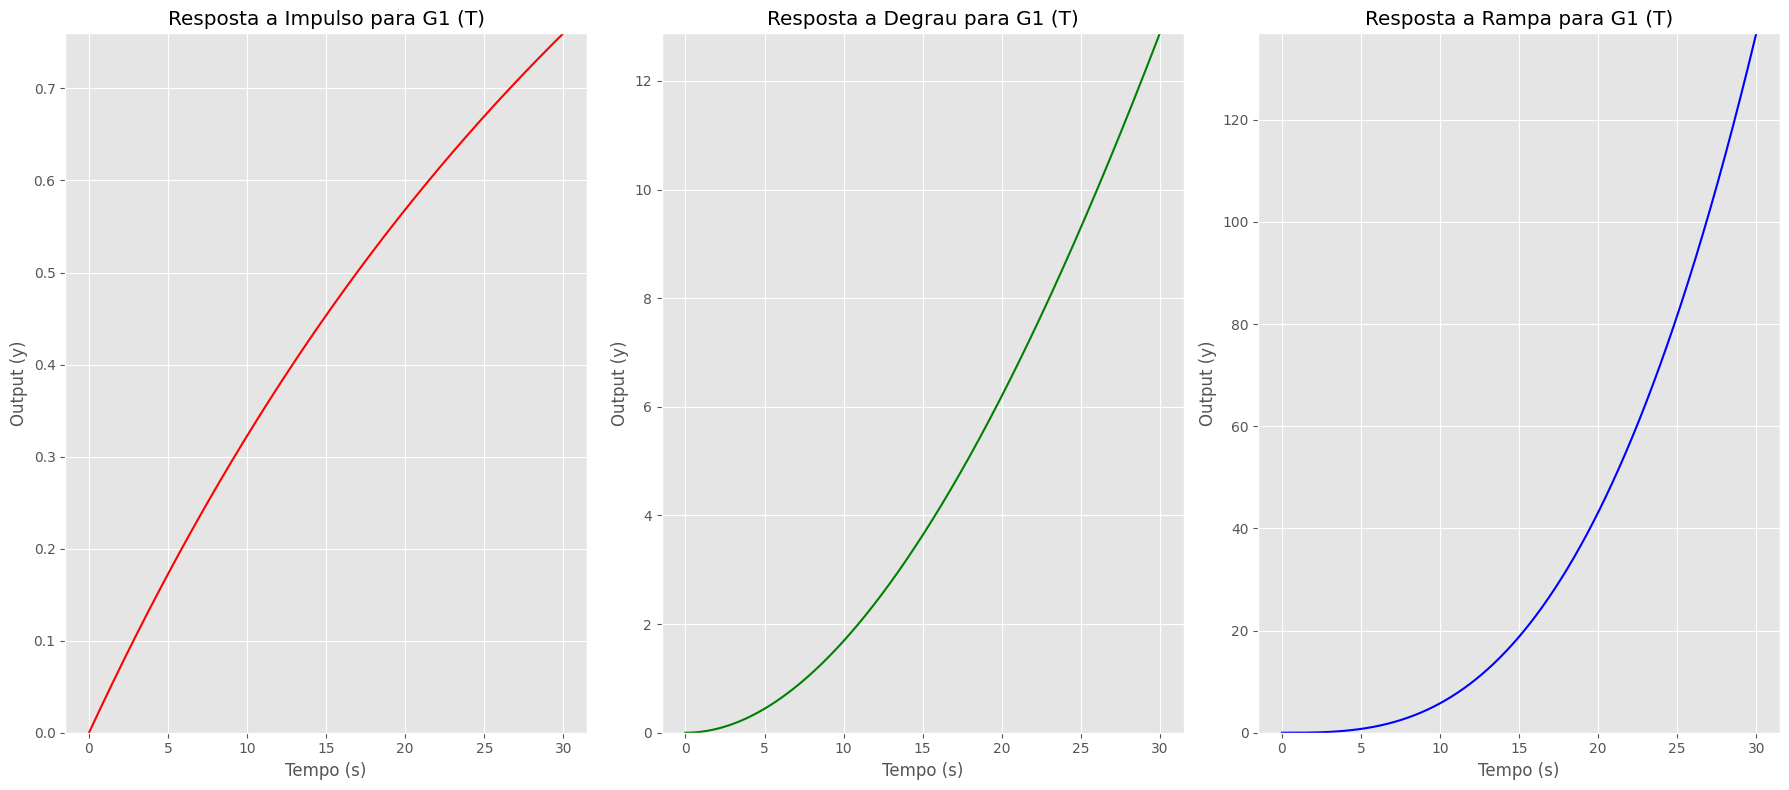

In [760]:
plt.figure(figsize=(18, 8))

# Calculate global min and max for y-axis across all responses
all_outputs = np.concatenate([rampG1.outputs, impulseG1.outputs, stepG1.outputs])
y_min = -25
y_max = np.max(all_outputs)

plt.subplot(1, 3, 1)
plt.plot(impulseG1.time, impulseG1.outputs, color='red')
plt.title("Resposta a Impulso para G1 (T)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (y)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True) # Apply global y-limits

plt.subplot(1, 3, 2)
plt.plot(stepG1.time, stepG1.outputs, color='green')
plt.title("Resposta a Degrau para G1 (T)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (y)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True) # Apply global y-limits

plt.subplot(1, 3, 3)
plt.plot(rampG1.time, rampG1.outputs, color='blue')
plt.title("Resposta a Rampa para G1 (T)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (y)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True) # Apply global y-limits

plt.tight_layout()
plt.show()

Resposta no Tempo para entradas Padrão em $G_2(s)$

In [761]:
stepG2 = ct.step_response(T2, np.linspace(0, 30, 500))
impulseG2 = ct.impulse_response(T2, np.linspace(0, 30, 500))
time_vector = np.linspace(0, 30, 500)
ramp_input = time_vector
rampG2 = ct.forced_response(T2, time_vector, ramp_input)

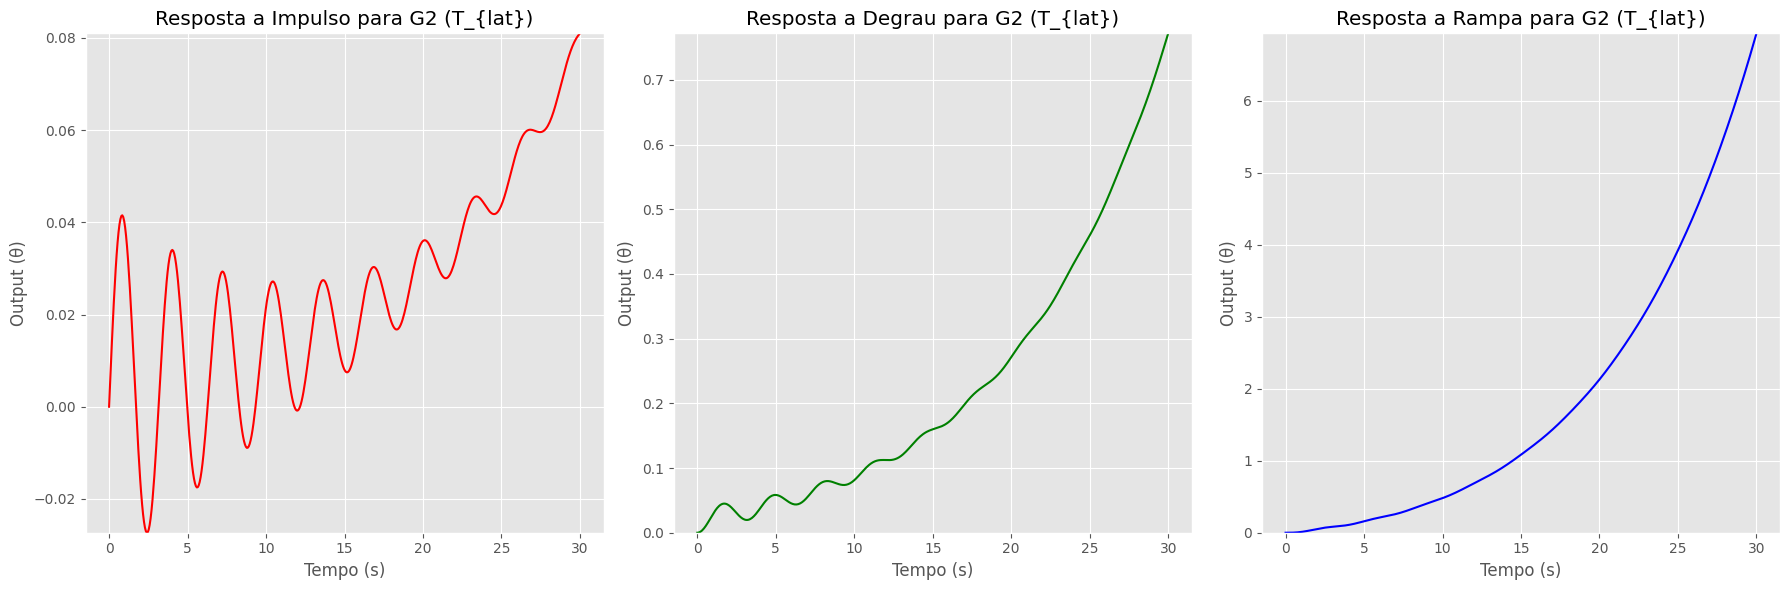

In [762]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(impulseG2.time, impulseG2.outputs, color='red')
plt.title("Resposta a Impulso para G2 (T_{lat})")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(1, 3, 2)
plt.plot(stepG2.time, stepG2.outputs, color='green')
plt.title("Resposta a Degrau para G2 (T_{lat})")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(1, 3, 3)
plt.plot(rampG2.time, rampG2.outputs, color='blue')
plt.title("Resposta a Rampa para G2 (T_{lat})")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.tight_layout()
plt.show()

Resposta no Tempo para entradas padrão em $G_3(s)$

In [763]:
stepG3 = ct.step_response(T3, np.linspace(0, 30, 500))
impulseG3 = ct.impulse_response(T3, np.linspace(0, 30, 500))
time_vector = np.linspace(0, 30, 500)
ramp_input = time_vector
rampG3 = ct.forced_response(T3, time_vector, ramp_input)

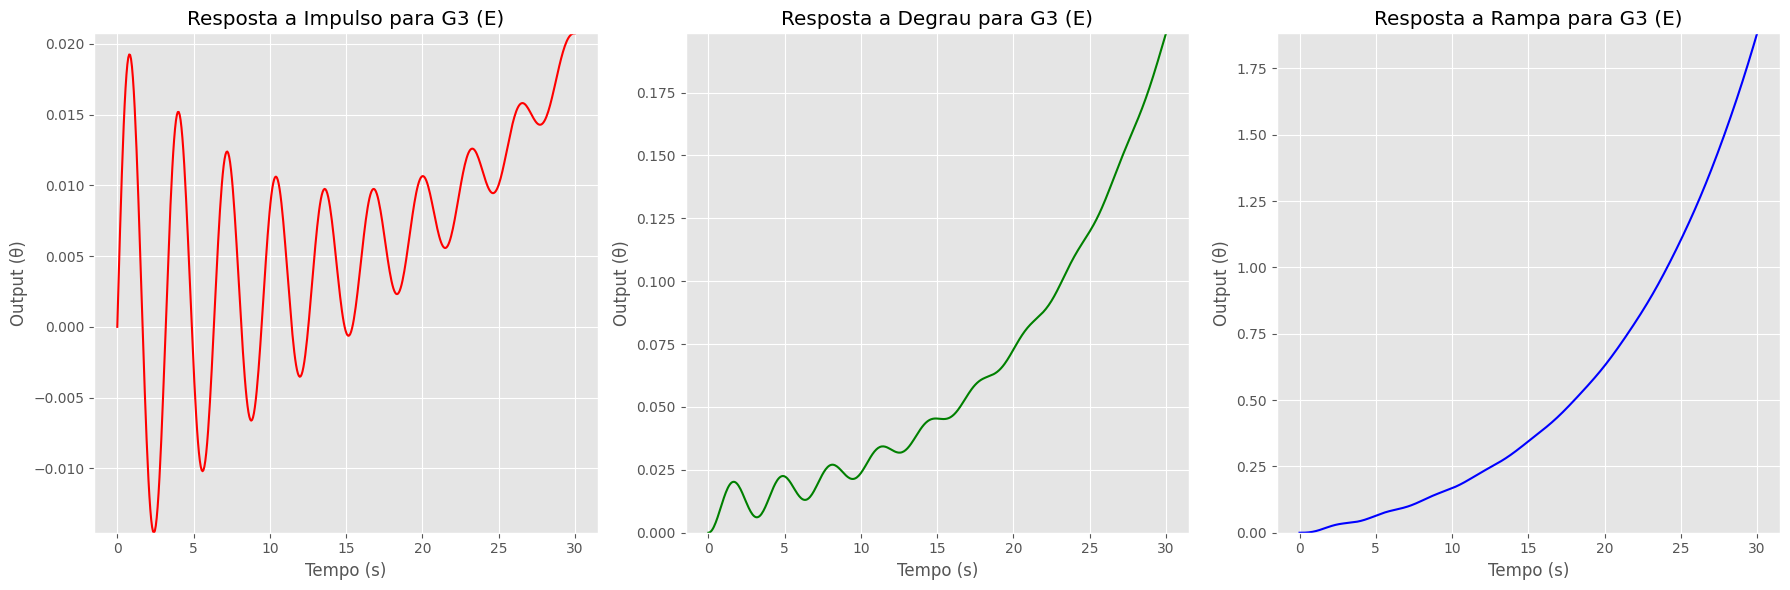

In [764]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(impulseG3.time, impulseG3.outputs, color='red')
plt.title("Resposta a Impulso para G3 (E)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(1, 3, 2)
plt.plot(stepG3.time, stepG3.outputs, color='green')
plt.title("Resposta a Degrau para G3 (E)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(1, 3, 3)
plt.plot(rampG3.time, rampG3.outputs, color='blue')
plt.title("Resposta a Rampa para G3 (E)")
plt.xlabel("Tempo (s)")
plt.ylabel("Output (θ)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.tight_layout()
plt.show()

### Simulações Numéricas
Simulações com condição inicial de $\dot y = 240 m/s$ e demais componentes zeradas, de forma a avaliar o efeito do vento sobre o foguete nos dois modelos possíveis, permitindo uma validação do modelo linearizado

Simulação Não Linearizada

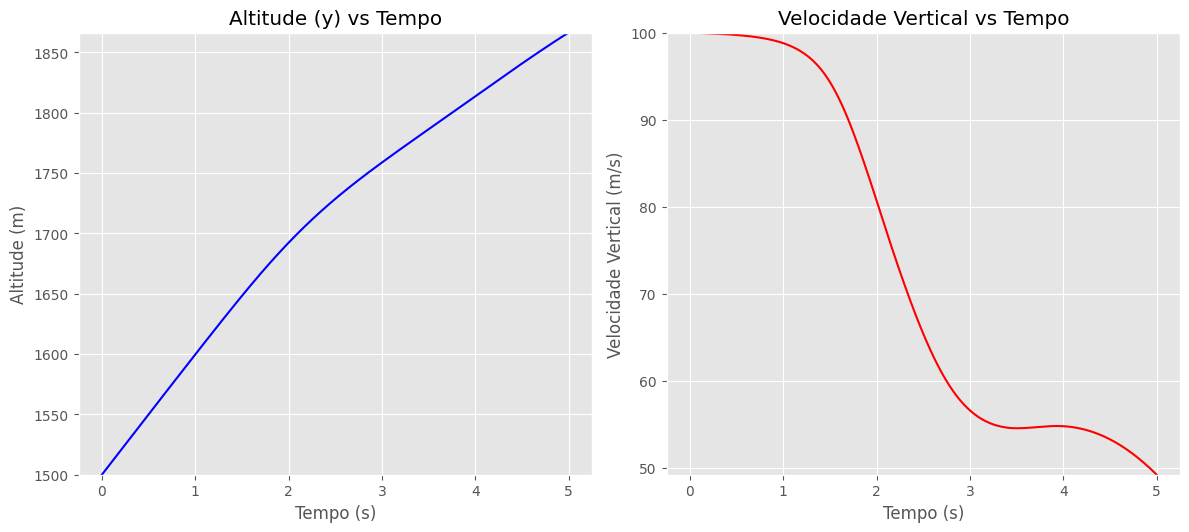

In [765]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

m = 27.0
T = T_eq[0]
Jg = 12.622
A_f = 0.021
A_m = 0.021
g = 9.81
rho = 1.225
D_Cp = 0.381
Cl = 1.5
Cd = 0.35
w = 6

# Definição das Equações Diferenciais
def dxdt(t, x):
    x, y, theta, vx, vy, omega = x

    if abs(vy) < 1e-3:
        vy = 1e-3

    vx_rel = vx - w
    vy_rel = vy
    v_sq = vx_rel**2 + vy_rel**2

    phi = np.pi/2 - np.arctan2(vx_rel, vy_rel)
    alpha = phi - theta

    D = 0.5 * rho * A_f * v_sq * Cd
    L = 0.5 * rho * A_m * v_sq * Cl * abs(alpha)

    fx = -L * np.cos(phi) - D * np.cos(phi) + T * np.cos(theta)
    ax = fx / m

    fy = L * np.sin(phi+np.pi) - D * np.sin(phi) + T * np.sin(theta) - m * g
    ay = fy / m

    torque = L * D_Cp * np.cos(alpha+np.pi) - D * D_Cp * np.sin(alpha)
    acc_theta = torque / Jg

    return [vx, vy, omega, ax, ay, acc_theta]

# Condições Iniciais
y0 = [0, 1500, np.pi/2, 0, V0, 0]

# Tempo de simulação (0 a 20 segundos)
t_span = (0, 5)
t_eval = np.linspace(0, 5, 500)

sol = solve_ivp(dxdt, t_span, y0, t_eval=t_eval, method='RK45')

# Visualização dos Resultados
plt.figure(figsize=(12, 10))

# Altitude
plt.subplot(2, 2, 1)
plt.plot(sol.t, sol.y[1], color='blue')
plt.title("Altitude (y) vs Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Altitude (m)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(2, 2, 2)
plt.plot(sol.t, sol.y[4], color='red')
plt.title("Velocidade Vertical vs Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Velocidade Vertical (m/s)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.tight_layout()
plt.show()

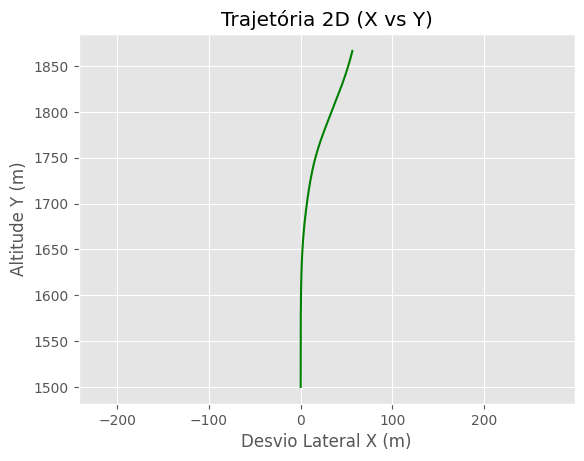

In [766]:
plt.plot(sol.y[0], sol.y[1], color='green')
plt.title("Trajetória 2D (X vs Y)")
plt.xlabel("Desvio Lateral X (m)")
plt.ylabel("Altitude Y (m)")
plt.axis('equal')
plt.grid(True)

Simulação do Sistema Linear

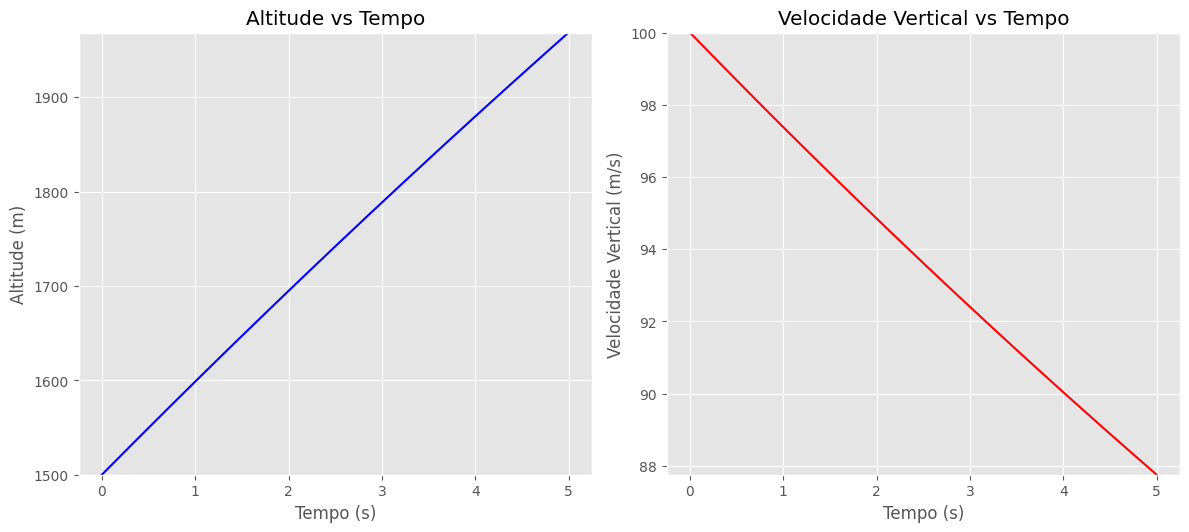

In [767]:
A_np = np.array(A)
B_np = np.array(B).astype(np.float64)
E_np = np.array(E).astype(np.float64)
deltaCd = 0
deltaw = 0
deltaT = 0
def lindxdt(t, x):
    BdCd = (B_np * deltaCd).flatten()
    Edw = (E_np * deltaw).flatten()
    dxdt = A_np@x #+ BdCd + Edw
    return dxdt.flatten()


y0 = [1500, 0, 0, V0, 0]

# Tempo de simulação (0 a 20 segundos)
t_span = (0, 5)
t_eval = np.linspace(0, 5, 500) # Pontos para o gráfico
A_np = np.array(A)
# 4. Execução (Integração Numérica)
sol_lin = solve_ivp(lindxdt, t_span, y0, t_eval=t_eval, method='RK45')

# 5. Visualização dos Resultados (Atualizando títulos para refletir variáveis incrementais)
plt.figure(figsize=(12, 10))

# Desvio Lateral Y Incremental
plt.subplot(2, 2, 1)
plt.plot(sol_lin.t, sol_lin.y[0], color='blue')
plt.title("Altitude vs Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Altitude (m)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.subplot(2, 2, 2)
plt.plot(sol_lin.t, sol_lin.y[3], color='red')
plt.title("Velocidade Vertical vs Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Velocidade Vertical (m/s)")
plt.grid(True)
plt.autoscale(enable=True, axis='y', tight=True)

plt.tight_layout()
plt.show()

(1500.0, 1968.5017693426878)

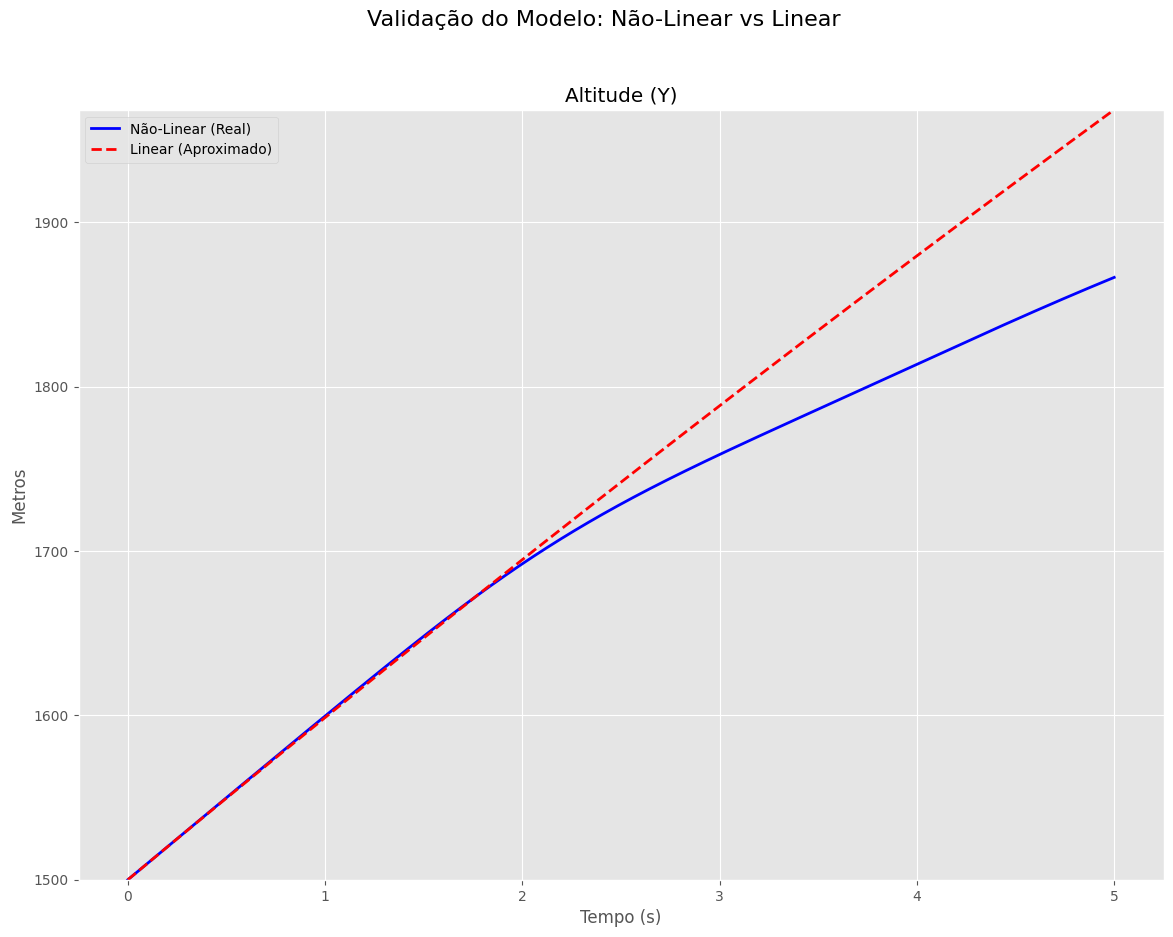

In [768]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
fig.suptitle("Validação do Modelo: Não-Linear vs Linear", fontsize=16)

# Non-linear altitude
altitude_nonlinear = sol.y[1]

# Linear altitude (add initial equilibrium altitude to incremental change)
altitude_linear_absolute = sol_lin.y[0]

ax.plot(sol.t, altitude_nonlinear, 'b-', label='Não-Linear (Real)', linewidth=2)
ax.plot(sol_lin.t, altitude_linear_absolute, 'r--', label='Linear (Aproximado)', linewidth=2)

ax.set_title("Altitude (Y)")
ax.set_ylabel("Metros")
ax.set_xlabel("Tempo (s)")
ax.legend()
ax.grid(True)

# Calculate common y-limits for both plots
min_y = min(np.min(altitude_nonlinear), np.min(altitude_linear_absolute))
max_y = max(np.max(altitude_nonlinear), np.max(altitude_linear_absolute))
ax.set_ylim(min_y, max_y)

A proximidade dos valores para t até ~2s demonstra que o sistema linearizado aproxima devidamente a dinâmica de voo, sendo o grande desvio criado após isso devido a instabilidade intrinseca ao sistema, que demonstra a incapacidade do modelo linear prever completamente o comportamento do foguete.

Além disso, o menor valor final de altitude deve-se pelo fato do modelo dinâmico capturar a força de arrasto como proporcional a $v^2$, enquanto o modelo linear captura como coeficiente constante na matriz $A$.

## Síntese de Regulador

Resposta do sistema não controlado

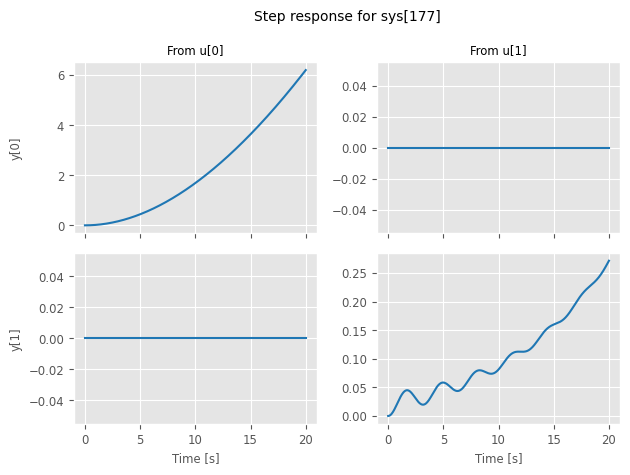

In [769]:
ST = ct.step_response(Rocket, np.linspace(0, 20, 500))
ST.plot()

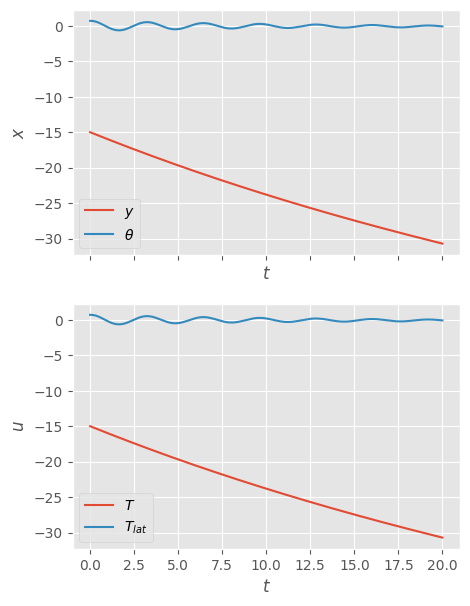

In [771]:
tsim = np.linspace(0, 20, 1001)
ws = np.linspace(0.1, 0.1, 1001)
x0 = [-15, 0.7, 2, -1, 0.1]
t_nc, u_nc, x_nc = ct.forced_response(Rocket, U=0, T=tsim, X0=x0, return_x=True)

fig, (state, control_input) = plt.subplots(
    2, 1, figsize=(5, 7), sharex=True)

state.plot(t_nc, x_nc[0, :],label=r'$y$')
state.plot(t_nc, x_nc[1, :], label=r'$\theta$')
state.set_ylabel(r'$x$')
state.set_xlabel(r'$t$')
state.legend()

control_input.plot(t_nc, u_nc[0],  label=r'$T$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.plot(t_nc, u_nc[1],  label=r'$T_{lat}$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.legend()

### Controlabilidade e Observabilidade

In [772]:
Wc = ct.ctrb(Rocket.A, Rocket.B)
rank_Wc = np.linalg.matrix_rank(Wc)


n_est = Rocket.A.shape[0]

éctr = (rank_Wc == n_est)

print(f"Estados(n): {n_est}")
print(f"Posto da Matriz de Controlabiliade: {rank_Wc}")
print(f"O sistema é totalmente controlável? {éctr}")

Estados(n): 5
Posto da Matriz de Controlabiliade: 5
O sistema é totalmente controlável? True


In [773]:
Cc = ct.ctrb(Rocket.A.transpose(), Rocket.C.transpose())
rank_Cc = np.linalg.matrix_rank(Cc)

n_est = Rocket.A.shape[0]

# 5. Evaluate the result
éobs = (rank_Cc == n_est)

print(f"Estados(n): {n_est}")
print(f"Posto da Matriz de Controlabiliade: {rank_Cc}")
print(f"O sistema é totalmente controlável? {éobs}")

Estados(n): 5
Posto da Matriz de Controlabiliade: 5
O sistema é totalmente controlável? True


### Síntese de LQR

In [774]:
Q = np.diag([100, 10000, 1, 100, 10]) #Pune fortemente os estados de posição, ângulo e velocidade vertical, enquanto pune menos as velocidades lateral e angular.
R = np.diag([1, 100]) #Pune o controle lateral, de forma a reduzir o uso dos propulsores laterais, buscando uso somente em ajustes finos.
K_lqr, S, p_lqr = ct.lqr(Rocket, Q, R)

In [775]:
p_lqr

array([-0.46878322+0.38808851j, -0.46878322-0.38808851j,
       -0.21971766+1.97668609j, -0.21971766-1.97668609j,
       -0.10700418+0.j        ])

In [776]:
Rocket_lqr = ct.ss(Rocket.A - Rocket.B @ K_lqr, B, Rocket.C, sp.zeros(2, 2))

/usr/local/lib/python3.12/dist-packages/control/pzmap.py:381: UserWarning: axis already exists; grid keyword ignored
  warnings.warn("axis already exists; grid keyword ignored")


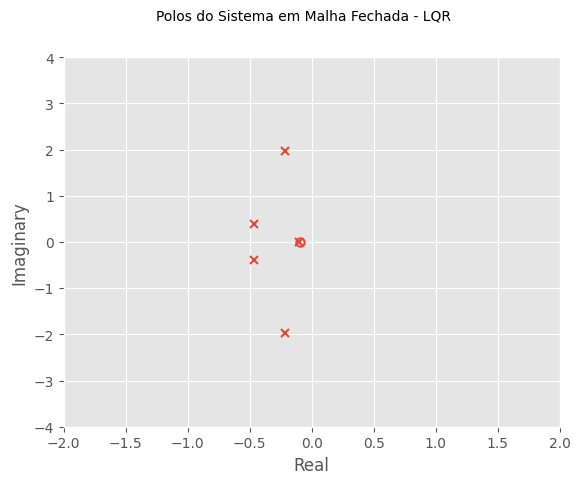

In [777]:
fig, ax = plt.subplots()
ct.pzmap(Rocket_lqr, title='Polos do Sistema em Malha Fechada - LQR', grid=True)
ax.set_aspect('auto')
plt.xlim([-2, 2])
plt.ylim([-4, 4])
plt.ylabel('Imaginary')
plt.xlabel('Real')
plt.show()

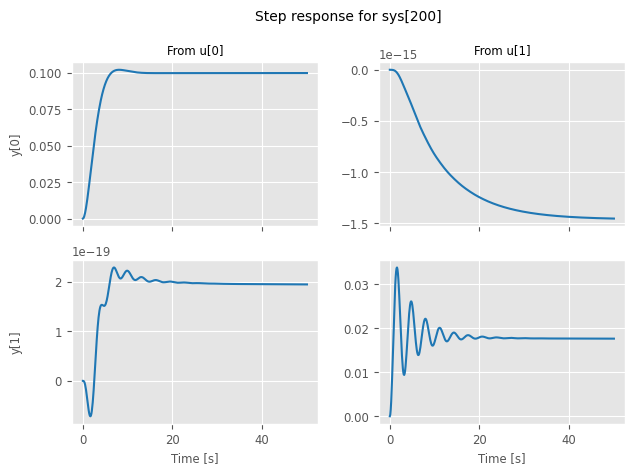

In [778]:
ST_lqr = ct.step_response(Rocket_lqr, np.linspace(0, 50, 500))
ST_lqr.plot()

### Alocação de Polos

A partir dos polos obtidos no LQR, deseja-se melhorar a resposta, principalmente quanto a entrada de empuxo lateral, buscando um transiente com melhores oscilações, aumentando seu amortecimento.

In [779]:
p_lqr

array([-0.46878322+0.38808851j, -0.46878322-0.38808851j,
       -0.21971766+1.97668609j, -0.21971766-1.97668609j,
       -0.10700418+0.j        ])

In [780]:
K_aloc = ct.place(Rocket.A, Rocket.B, [-0.8+2j, -0.8-2j, -0.7+0.37j, -0.7-0.37j, -1] )

In [781]:
Rocket_loc = ct.ss(Rocket.A - Rocket.B @ K_aloc, B, Rocket.C, sp.zeros(2, 2))

/usr/local/lib/python3.12/dist-packages/control/pzmap.py:381: UserWarning: axis already exists; grid keyword ignored
  warnings.warn("axis already exists; grid keyword ignored")


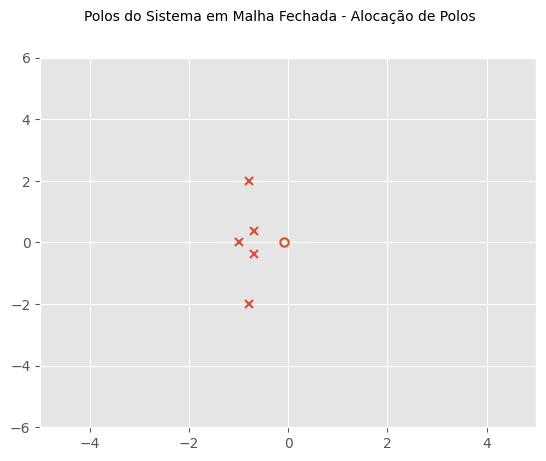

In [782]:
fig, ax = plt.subplots()
ct.pzmap(Rocket_loc, title='Polos do Sistema em Malha Fechada - Alocação de Polos', grid=True)
ax.set_aspect('auto')
plt.xlim([-5, 5])
plt.ylim([-6, 6])

plt.show()

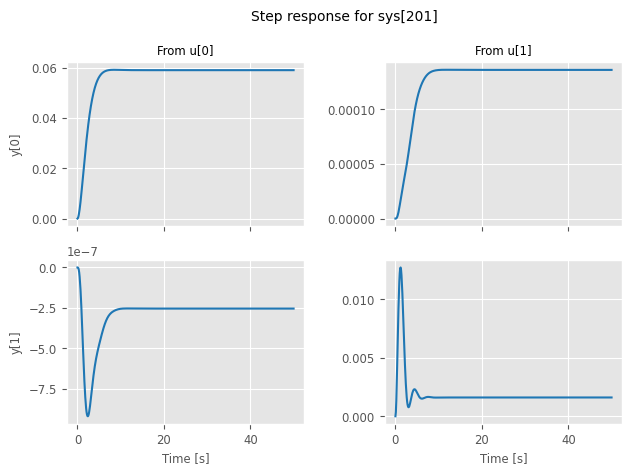

In [783]:
ST_loc = ct.step_response(Rocket_loc, np.linspace(0, 50, 500))
ST_loc.plot()

In [784]:
print(K_aloc)

[[ 1.69301733e+01 -1.37329870e-02  6.87009840e-03  3.70223511e+01
  -6.64651638e-02]
 [ 2.67971893e-03  2.72229452e+01 -3.13017205e+00  1.21814785e-03
   3.03930857e+01]]


### Resposta do Sistema Controlado

In [785]:
Rocket_CTR_LQR = ct.ss(Rocket.A - Rocket.B @ K_lqr, E, -K_lqr, np.zeros((2, 1)))
Rocket_CTR_ALC = ct.ss(Rocket.A - Rocket.B @ K_aloc, E, -K_aloc, np.zeros((2, 1)))

Resposta Via LQR

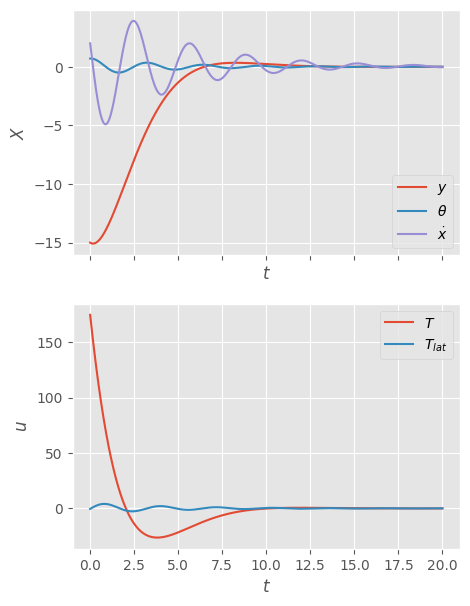

In [786]:
t_lq, u_lq, x_lq = ct.forced_response(Rocket_CTR_LQR, U=0, T=tsim, X0=x0, return_x=True)

fig, (state, control_input) = plt.subplots(
    2, 1, figsize=(5, 7), sharex=True)

state.plot(t_lq, x_lq[0, :],label=r'$y$')
state.plot(t_lq, x_lq[1, :], label=r'$\theta$')
state.plot(t_lq, x_lq[2, :], label=r'$\dot x$')
state.set_ylabel(r'$X$')
state.set_xlabel(r'$t$')
state.legend()

control_input.plot(t_lq, u_lq[0],  label=r'$T$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.plot(t_lq, u_lq[1],  label=r'$T_{lat}$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.legend()

Resposta Via Alocação de Polos

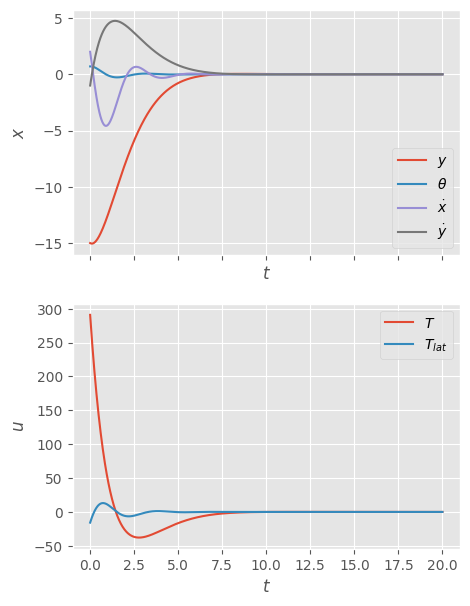

In [787]:
t_aloc, u_aloc, x_aloc = ct.forced_response(Rocket_CTR_ALC, U=0, T=tsim, X0=x0, return_x=True)

fig, (state, control_input) = plt.subplots(
    2, 1, figsize=(5, 7), sharex=True)

state.plot(t_aloc, x_aloc[0, :],label=r'$y$')
state.plot(t_aloc, x_aloc[1, :], label=r'$\theta$')
state.plot(t_lq, x_aloc[2, :], label=r'$\dot x$')
state.plot(t_lq, x_aloc[3, :], label=r'$\dot y$')
state.set_ylabel(r'$x$')
state.set_xlabel(r'$t$')
state.legend()

control_input.plot(t_aloc, u_aloc[0],  label=r'$T$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.plot(t_aloc, u_aloc[1],  label=r'$T_{lat}$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.legend()

## Síntese de Observador

In [788]:
T = np.eye(5)#[::-1]  # ou no caso mais geral, use V = la.null_space(C).T
V = T[2:5,]
C = T[0:2,]
M = T.transpose()[:, 0:2]
N = T.transpose()[:, 2:5]

A11 = C @ A @ M
A12 = C @ A @ N
A21 = V @ A @ M
A22 = V @ A @ N

In [789]:
Bo1 = T[0:2,] @ B
Bo2 = T[2:5,] @ B

In [790]:
Obs2 = ct.obsv(A22, A12)
rank_obs2 = np.linalg.matrix_rank(Obs2)
print("--- Observabilidade de (A22, A12) ---")
print("Rank:", rank_obs2)

--- Observabilidade de (A22, A12) ---
Rank: 3


In [791]:
Rocket_loc.poles()

array([-0.8+2.j  , -0.8-2.j  , -0.7+0.37j, -0.7-0.37j, -1. +0.j  ])

In [792]:
J = (ct.place(A22.T, A12.T, [-6, -10 + 1j, -10 -1j])).T
J

array([[-1.51966407e+02, -1.54674216e+03],
       [ 9.88643720e+00, -4.13283871e-01],
       [ 1.56539843e+00,  1.60086386e+01]])

In [793]:
F = A22 - J @ A12
G = A21  - J @ A11 + F @ J
H = Bo2 - J @ Bo1
S = M + N @ J

In [794]:
Aa = np.block([[A, np.zeros((5, 5-2))],
          [G @ C, F]])
Ba = np.block([[B], [H]])
Ea = np.block([[E], [np.zeros((5-2, 1))]])
Ca = np.block([[C, np.zeros((2, 5-2))]])

In [795]:
Aa_c = Aa - (Ba @ K_aloc @ np.block([S @ C, N]))
Aa_c

array([[0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [19.3804819775481, 180.696680936890, -0.0761214807965823, 0, 0,
        -0.115932298268761, 4.51165870843763e-5, 1.12566984113189],
       [-14.1406440547969, 1.00017634051484, 0, -0.0288027224635717, 0,
        -0.000254448088879917, -1.37119818785779, 0.00246167273187053],
       [-41.4572186177943, -428.142946032179, -0.0385650504651942, 0, 0,
        0.247993349172598, -9.65098915606212e-5, -2.40794531061329],
       [3954.62249223509, 24996.8680111707, 0, 0, 0, -0.192053779065343,
        151.966452609524, 1547.86783254868],
       [-111.520086864692, 11.7140972057377, 0, 0, 0,
        -0.000254448088879917, -11.2864381061703, 0.415745543711531],
       [-76.1327375347325, -624.122312400378, 0, 0, 0, 0.209428298707404,
        -1.56549494352044, -18.4165839115042]], dtype=object)

In [796]:
Rocket_Obs = ct.ss(Aa_c, Ea, -K_aloc @ np.block([S @ C, N]), np.zeros((2, 1)))

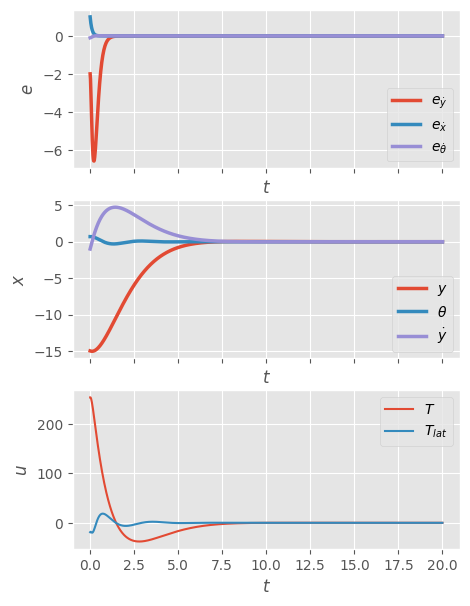

In [797]:
z0 = [0, 0, 0] - J @ C @ x0
t_obs, u_obs, x_obs = ct.forced_response(Rocket_Obs, U=0, T=tsim, X0=np.append(x0, z0), return_x=True)
xe = S @ C @ x_obs[0:5, :] + N @ x_obs[5:, :]

fig, (errors, state, control_input) = plt.subplots(
    3, 1, figsize=(5, 7), sharex=True)

errors.plot(t_obs, xe[2, :] - x_obs[2, :], linewidth=2.5,
           label=r'$e_{\dot y}$')
errors.plot(t_obs, xe[3, :] - x_obs[3, :], linewidth=2.5,
            label=r'$e_{\dot x}$')
errors.plot(t_obs, xe[4, :] - x_obs[4, :], linewidth=2.5,
            label=r'$e_{\dot \theta}$')
errors.set_ylabel(r'$e$')
errors.set_xlabel(r'$t$')
errors.legend()

state.plot(t_obs, x_obs[0, :], linewidth=2.5,
           label=r'${y}$')
state.plot(t_obs, x_obs[1, :], linewidth=2.5,
           label=r'${\theta}$')
state.plot(t_obs, x_obs[3, :], linewidth=2.5,
           label=r'${\dot y}$')
state.set_ylabel(r'$x$')
state.set_xlabel(r'$t$')
state.legend()

control_input.plot(t_obs, u_obs[0],  label=r'$T$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.plot(t_obs, u_obs[1],  label=r'$T_{lat}$')
control_input.set_ylabel(r'$u$')
control_input.set_xlabel(r'$t$')
control_input.legend()

## Pré Alimentação via Modelos Assumidos

Aqui define-se um modelo para seguidor de referência, afim de que seja possível manipular o comportamento do foguete quanto a sua trajetória, além de verificar sua capacidade de rejeição de perturbações. A trajetória aqui assumida será a altitude em uma função do tipo seno, buscando aproximar um comportamento de subida/decolagem e descida/pouso, e uma velocidade lateral constante.

In [798]:
ω_s = 2.0        # [rad/s]
ζ_s = 0

Ar = np.array([[0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [-ω_s ** 2, 0, 0, -2 * ζ_s * ω_s, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]])



In [799]:
# seleção de variável para seguir referência
M_ref = np.array([
    [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0]
]).astype(np.float64)

# inversa da matriz de estados em MF
A_cl_inv = np.linalg.inv(Aa_c.astype(np.float64))

# ganho de pré-alimentação
termo_inverso = np.linalg.inv(M_ref @ A_cl_inv @ Ba.astype(np.float64))
Ns = termo_inverso @ M_ref @ A_cl_inv
G_r = Ns @ (Aa.astype(np.float64) - Ar)

In [800]:
K_co = K_aloc @ np.block([S @ C, N])
A_ex_cl = np.block([[Aa - Ba @ K_co , Ba @ (K_co  - G_r)],
                    [np.zeros((8, 8)), Ar]])
E_ex_cl = np.block([[Ea], [np.zeros((8, 1))]])
K_ex = np.block([[-K_co, K_co - G_r]])

# forma de espaço de estados
Rocket_Seg = ct.ss(A_ex_cl, E_ex_cl, K_ex, 0)
Rocket_Seg

StateSpace(
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 1.93804820e+01,  1.80696681e+02, -7.61214808e-02,
         0.00000000e+00,  0.00000000e+00, -1.15932298e-01,
         4.51165871e-05,  1.12566984e+00, -5.33175746e-02,
        -1.98741435e-12,  1.11509757e-01,  3.83208167e-04,
         0.00000000e+00,  8.38835174e-16, -1.40707838e-14,
        -5.21064673e-14],
       [-1.41406441e+01, 

In [801]:
# Parâmetros
v_xr = 3.0 # [m/s] constante
amp_y = 10.0
v0_yr = amp_y * ω_s

# [yr, theta_r, vx_r, vy_r, vtheta_r, z1, z2, z3]
x0_seg = np.array([-15, 0.7, 2, -1, 0.1])
xr0 = np.array([0.0, 0.0, v_xr, v0_yr, 0.0, 0.0, 0.0, 0.0])

Xi = np.concatenate((x0_seg, z0, xr0))

# Simulação
tsim = np.linspace(0, 25, 1001)
y0_medido = C @ x0_seg
z0 = np.array([0.0, 0.0, 0.0]) - J @ y0_medido
tss, u, x_sims = ct.forced_response(Rocket_Seg, U=0, T=tsim, X0=Xi, return_x=True)

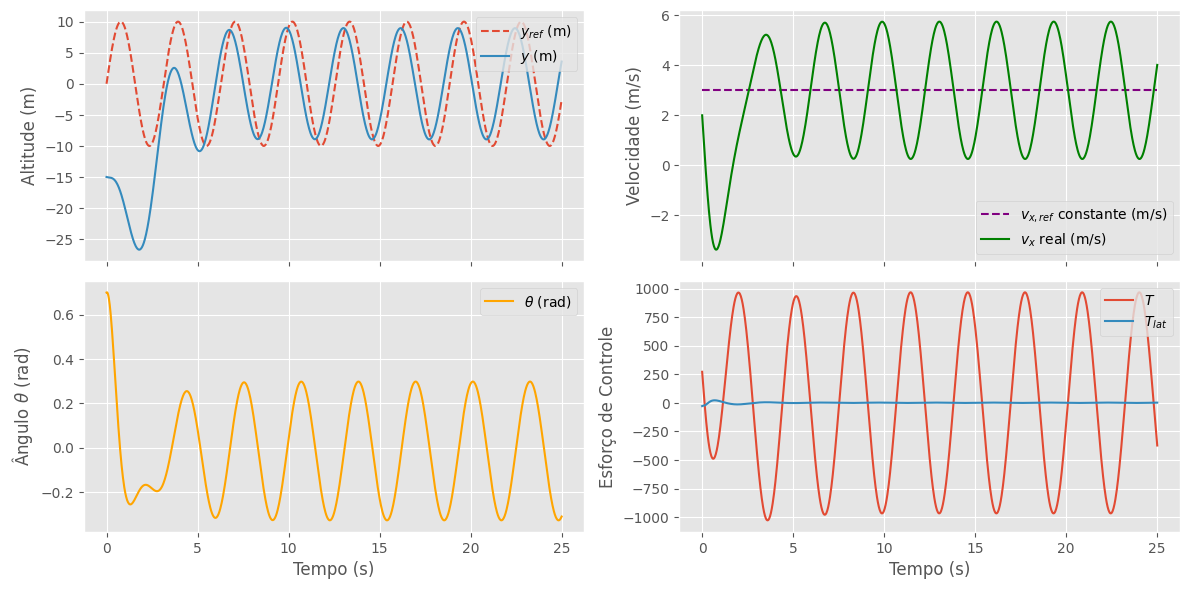

In [802]:

fig, ((ax_alt, ax_vel), (ax_att, ax_u)) = plt.subplots(2, 2, figsize=(12, 6), sharex=True)


# Gráfico 1: Altitude (Senoide) [Canto Superior Esquerdo]
ax_alt.plot(tss, x_sims[8, :], '--', label=r'$y_{ref}$ (m)')
ax_alt.plot(tss, x_sims[0, :], label=r'$y$ (m)')
ax_alt.set_ylabel(r'Altitude (m)')
ax_alt.legend(loc='upper right')
ax_alt.grid(True)

# Gráfico 2: Velocidade Horizontal [Canto Superior Direito]
ax_vel.plot(tss, x_sims[10, :], '--', color='purple', label=r'$v_{x,ref}$ constante (m/s)')
ax_vel.plot(tss, x_sims[2, :], color='green', label=r'$v_x$ real (m/s)')
ax_vel.set_ylabel(r'Velocidade (m/s)')
ax_vel.legend(loc='lower right')
ax_vel.grid(True)



# Gráfico 3: Ângulo [Canto Inferior Esquerdo]
ax_att.plot(tss, x_sims[1, :], color='orange', label=r'$\theta$ (rad)')
ax_att.set_ylabel(r'Ângulo $\theta$ (rad)')
ax_att.set_xlabel(r'Tempo (s)') # Eixo X na base
ax_att.legend(loc='upper right')
ax_att.grid(True)

# Gráfico 4: Esforço de Controle [Canto Inferior Direito]
ax_u.plot(tss, u[0, :], label=r'$T$')
ax_u.plot(tss, u[1, :], label=r'$T_{lat}$')
ax_u.set_ylabel(r'Esforço de Controle')
ax_u.set_xlabel(r'Tempo (s)') # Eixo X na base
ax_u.legend(loc='upper right')
ax_u.grid(True)

plt.tight_layout()
plt.show()

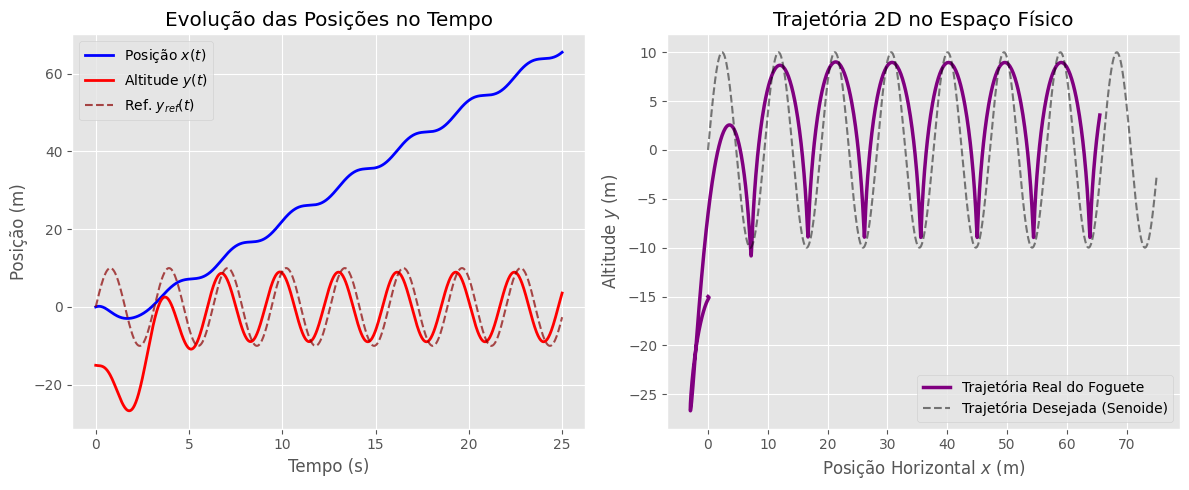

In [803]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid


# 1. Recuperando as variáveis para o plot
# y real é o estado 0. y de referência é o estado 8 (no sistema aumentado).
y_pos = x_sims[0, :]
y_ref = x_sims[8, :]

# v_x real é o estado 2. v_x de referência é o estado 10.
vx_real = x_sims[2, :]
vx_ref = x_sims[10, :]

# 2. Integrando as velocidades para obter a posição horizontal x(t)
x_pos = cumulative_trapezoid(vx_real, tss, initial=0.0)
x_ref = cumulative_trapezoid(vx_ref, tss, initial=0.0)

# 3. Plotagem Especial da Trajetória
fig_traj, (ax_time, ax_xy) = plt.subplots(1, 2, figsize=(12, 5))

# --- GRÁFICO 1: Posições vs Tempo ---
ax_time.plot(tss, x_pos, label=r'Posição $x(t)$', color='blue', linewidth=2)
ax_time.plot(tss, y_pos, label=r'Altitude $y(t)$', color='red', linewidth=2)
ax_time.plot(tss, y_ref, '--', label=r'Ref. $y_{ref}(t)$', color='darkred', alpha=0.7)
ax_time.set_xlabel('Tempo (s)')
ax_time.set_ylabel('Posição (m)')
ax_time.set_title('Evolução das Posições no Tempo')
ax_time.legend(loc='upper left')
ax_time.grid(True)

# --- GRÁFICO 2: Trajetória 2D no Espaço (y vs x) ---
ax_xy.plot(x_pos, y_pos, label='Trajetória Real do Foguete', color='purple', linewidth=2.5)
ax_xy.plot(x_ref, y_ref, '--', label='Trajetória Desejada (Senoide)', color='black', alpha=0.5)

ax_xy.set_xlabel('Posição Horizontal $x$ (m)')
ax_xy.set_ylabel('Altitude $y$ (m)')
ax_xy.set_title('Trajetória 2D no Espaço Físico')
ax_xy.legend(loc='lower right')
ax_xy.grid(True)

plt.tight_layout()
plt.show()

Gerando e salvando o GIF animado com atitude... Aguarde!
Sucesso! Abra o arquivo 'trajetoria_foguete_com_angulo.gif' para ver o voo.


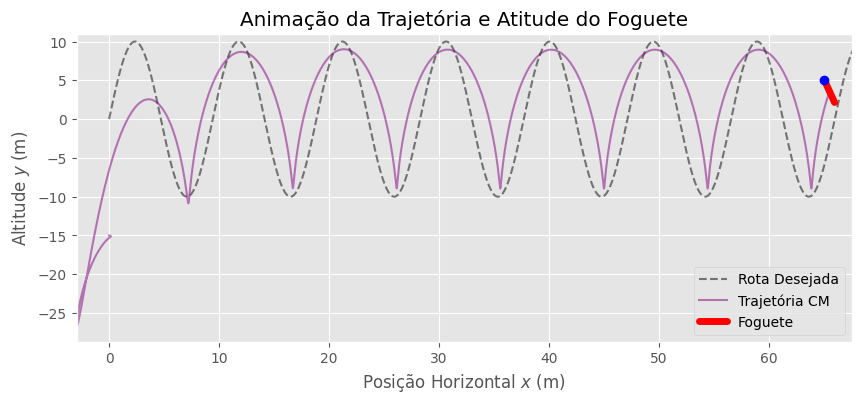

In [804]:
import matplotlib.animation as animation
import numpy as np

# 1. Recuperando o ângulo real do vetor de estados simulado
theta_real = x_sims[1, :]

# Tamanho do foguete no gráfico (em metros). Ajuste para ficar visualmente agradável!
L = 3.0

# 2. Configurando a figura
fig_anim, ax_anim = plt.subplots(figsize=(10, 4))
ax_anim.set_xlim(np.min(x_pos), np.max(x_pos) + 2)
ax_anim.set_ylim(np.min(y_pos) - 2, np.max(y_pos) + 2)

ax_anim.set_xlabel('Posição Horizontal $x$ (m)')
ax_anim.set_ylabel('Altitude $y$ (m)')
ax_anim.set_title('Animação da Trajetória e Atitude do Foguete')
ax_anim.grid(True)

# 3. Criando os objetos gráficos
linha_ref, = ax_anim.plot([], [], '--', color='black', alpha=0.5, label='Rota Desejada')
linha_real, = ax_anim.plot([], [], color='purple', linewidth=1.5, alpha=0.5, label='Trajetória CM')

# O Foguete: Uma linha grossa para o corpo e um ponto para o "bico" (para sabermos onde é a frente)
foguete_corpo, = ax_anim.plot([], [], color='red', linewidth=5, solid_capstyle='round', label='Foguete')
foguete_bico, = ax_anim.plot([], [], 'o', color='blue', markersize=6)

ax_anim.legend(loc='lower right')

def init():
    linha_ref.set_data([], [])
    linha_real.set_data([], [])
    foguete_corpo.set_data([], [])
    foguete_bico.set_data([], [])
    return linha_ref, linha_real, foguete_corpo, foguete_bico

def update(frame):
    # Rastro da trajetória até o frame atual
    linha_ref.set_data(x_ref[:frame], y_ref[:frame])
    linha_real.set_data(x_pos[:frame], y_pos[:frame])

    # Posição do Centro de Massa (CM) e Ângulo no instante atual
    x_cm = x_pos[frame]
    y_cm = y_pos[frame]
    theta = theta_real[frame]

    # Calculando as pontas do bastão com trigonometria
    # (Se o foguete inclinar para o lado errado na animação, basta inverter o sinal de dx)
    dx = (L / 2.0) * np.sin(theta)
    dy = (L / 2.0) * np.cos(theta)

    # Coordenadas da base (motor) e do bico
    x_base = x_cm - dx
    y_base = y_cm - dy
    x_bico = x_cm + dx
    y_bico = y_cm + dy

    # Atualiza o corpo (linha conectando a base ao bico)
    foguete_corpo.set_data([x_base, x_bico], [y_base, y_bico])

    # Atualiza o ponto azul (bico) para mostrar a orientação
    foguete_bico.set_data([x_bico], [y_bico])

    return linha_ref, linha_real, foguete_corpo, foguete_bico

# Pulando frames para renderizar mais rápido (ajuste se quiser mais fluido ou mais leve)
frames_pulados = np.arange(0, len(tss), 4)

ani = animation.FuncAnimation(fig_anim, update, frames=frames_pulados,
                              init_func=init, blit=True, interval=20)

print("Gerando e salvando o GIF animado com atitude... Aguarde!")
ani.save('trajetoria_foguete_com_angulo.gif', writer='pillow', fps=30)
print("Sucesso! Abra o arquivo 'trajetoria_foguete_com_angulo.gif' para ver o voo.")

plt.show()

Simulação em Malha Fechada para Seguidor de Referência sob Perturbação

In [805]:
import numpy as np
import control as ct

tsim = np.linspace(0, 25, 1001)
x0_seg = np.array([-15.0, 0.7, 2.0, -1.0, 0.1])

y0_medido = C @ x0_seg
z0 = np.array([0.0, 0.0, 0.0]) - J @ y0_medido
xr0 = np.array([0.0, 0.0, v_xr, v0_yr, 0.0, 0.0, 0.0, 0.0])
Xi = np.concatenate((x0_seg, z0, xr0))

# Perfil de vento
w_vento = 10*np.sin(tsim)

# Simulação com Resposta Forçada
tp, u_sim, x_sim = ct.forced_response(Rocket_Seg, T=tsim, U=w_vento, X0=Xi, return_x=True)

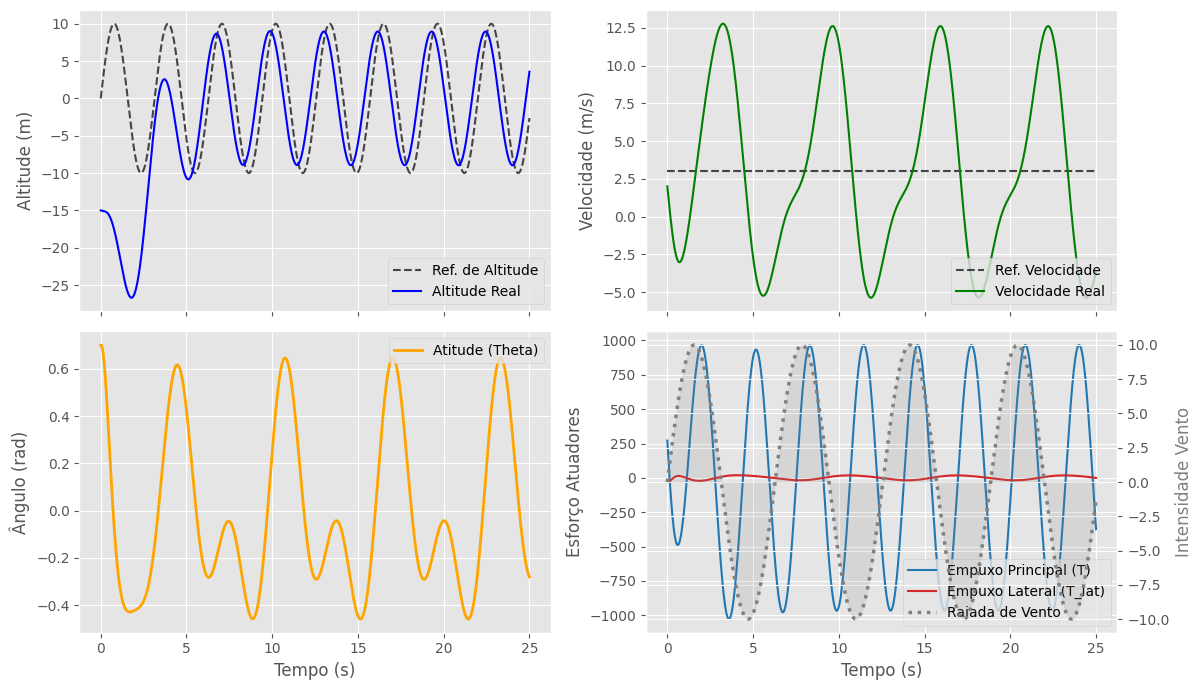

In [806]:
import matplotlib.pyplot as plt

# Criando a figura com um grid 2x2
fig, ((ax_alt, ax_vel), (ax_att, ax_u)) = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

# --- LINHA SUPERIOR ---

# Gráfico 1: Altitude [Canto Superior Esquerdo]
ax_alt.plot(tsim, x_sim[8, :], '--', label='Ref. de Altitude', color='black', alpha=0.7)
ax_alt.plot(tsim, x_sim[0, :], label='Altitude Real', color='blue')
ax_alt.set_ylabel('Altitude (m)')
ax_alt.legend(loc='lower right')
ax_alt.grid(True)

# Gráfico 2: Velocidade Horizontal [Canto Superior Direito]
ax_vel.plot(tsim, x_sim[10, :], '--', color='black', alpha=0.7, label='Ref. Velocidade')
ax_vel.plot(tsim, x_sim[2, :], color='green', label='Velocidade Real')
ax_vel.set_ylabel('Velocidade (m/s)')
ax_vel.legend(loc='lower right')
ax_vel.grid(True)


# --- LINHA INFERIOR ---

# Gráfico 3: Ângulo [Canto Inferior Esquerdo]
ax_att.plot(tsim, x_sim[1, :], color='orange', linewidth=2, label='Atitude (Theta)')
ax_att.set_ylabel('Ângulo (rad)')
ax_att.set_xlabel('Tempo (s)')
ax_att.legend(loc='upper right')
ax_att.grid(True)

# Gráfico 4: Esforço de Controle + Perfil de Vento [Canto Inferior Direito]
ax_u.plot(tsim, u_sim[0, :], label='Empuxo Principal (T)', color='tab:blue')
ax_u.plot(tsim, u_sim[1, :], label='Empuxo Lateral (T_lat)', color='tab:red')
ax_u.set_ylabel('Esforço Atuadores')
ax_u.set_xlabel('Tempo (s)')
ax_u.grid(True)

# O Pulo do Gato: Eixo Y secundário para o vento!
ax_vento = ax_u.twinx()
ax_vento.plot(tsim, w_vento, color='gray', linestyle=':', linewidth=2.5, label='Rajada de Vento')
ax_vento.fill_between(tsim, 0, w_vento, color='gray', alpha=0.15) # Sombreia a área com vento
ax_vento.set_ylabel('Intensidade Vento', color='gray')

# Juntando as legendas dos atuadores e do vento no mesmo quadro
lines_u, labels_u = ax_u.get_legend_handles_labels()
lines_v, labels_v = ax_vento.get_legend_handles_labels()
ax_u.legend(lines_u + lines_v, labels_u + labels_v, loc='lower right')

plt.tight_layout()
plt.show()

Ressalta-se aqui que há seguimento de referência em altitude e em $\dot x$, não no posicionamento $x$, o que explica o comportamento da trajetória descrita abaixo

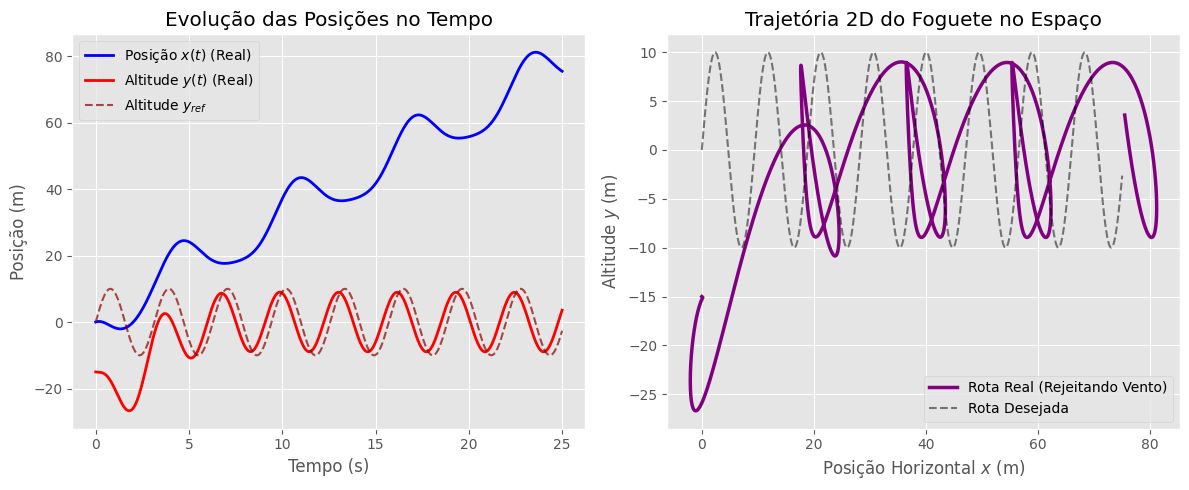

In [809]:
import numpy as np
from scipy.integrate import cumulative_trapezoid

# 1. Recuperando as variáveis da sua simulação com vento
y_pos = x_sim[0, :]
y_ref = x_sim[8, :]

vx_real = x_sim[2, :]
vx_ref = x_sim[10, :]

# 2. Integrando as velocidades no novo vetor de tempo (tsim) para obter a posição x(t)
x_pos = cumulative_trapezoid(vx_real, tsim, initial=0.0)
x_ref = cumulative_trapezoid(vx_ref, tsim, initial=0.0)

# 3. Plotagem da Trajetória 2D
fig_traj, (ax_time, ax_xy) = plt.subplots(1, 2, figsize=(12, 5))

# --- GRÁFICO 1: Evolução das Posições vs Tempo ---
ax_time.plot(tsim, x_pos, label=r'Posição $x(t)$ (Real)', color='blue', linewidth=2)
ax_time.plot(tsim, y_pos, label=r'Altitude $y(t)$ (Real)', color='red', linewidth=2)
ax_time.plot(tsim, y_ref, '--', label=r'Altitude $y_{ref}$', color='darkred', alpha=0.7)
ax_time.set_xlabel('Tempo (s)')
ax_time.set_ylabel('Posição (m)')
ax_time.set_title('Evolução das Posições no Tempo')
ax_time.legend(loc='upper left')
ax_time.grid(True)

# --- GRÁFICO 2: Trajetória 2D no Espaço (y vs x) ---
ax_xy.plot(x_pos, y_pos, label='Rota Real (Rejeitando Vento)', color='purple', linewidth=2.5)
ax_xy.plot(x_ref, y_ref, '--', label='Rota Desejada', color='black', alpha=0.5)

ax_xy.set_xlabel('Posição Horizontal $x$ (m)')
ax_xy.set_ylabel('Altitude $y$ (m)')
ax_xy.set_title('Trajetória 2D do Foguete no Espaço')
ax_xy.legend(loc='lower right')
ax_xy.grid(True)

# Garante que os eixos tenham a mesma proporção (opcional, comente se distorcer muito)
# ax_xy.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

Renderizando e salvando o GIF... Aguarde!
Sucesso! O arquivo 'foguete_com_vento.gif' foi salvo na pasta do seu projeto.


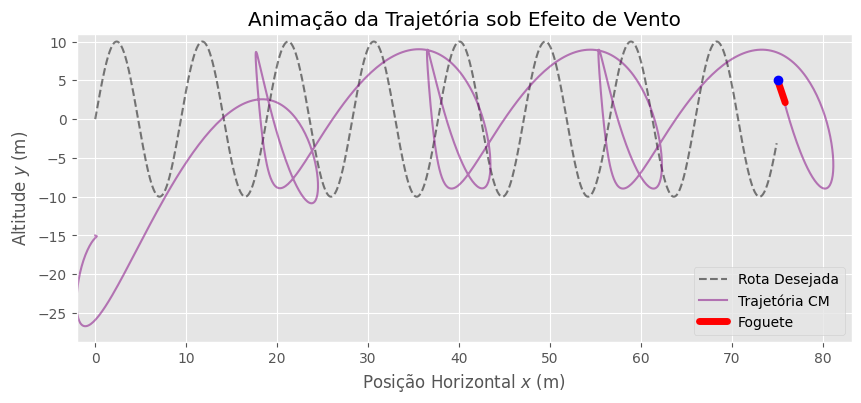

In [810]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import cumulative_trapezoid

# 1. Recuperando os dados do vetor x_sim
y_pos = x_sim[0, :]
y_ref = x_sim[8, :]
vx_real = x_sim[2, :]
vx_ref = x_sim[10, :]
theta_real = x_sim[1, :]

# 2. Integrando a velocidade no tempo (tsim) para obter as posições horizontais x
x_pos = cumulative_trapezoid(vx_real, tsim, initial=0.0)
x_ref = cumulative_trapezoid(vx_ref, tsim, initial=0.0)

# Tamanho visual do foguete no gráfico (em metros)
L = 3.0

# 3. Configurando a figura
fig_anim, ax_anim = plt.subplots(figsize=(10, 4))
ax_anim.set_xlim(np.min(x_pos), np.max(x_pos) + 2)
ax_anim.set_ylim(np.min(y_pos) - 2, np.max(y_pos) + 2)

ax_anim.set_xlabel('Posição Horizontal $x$ (m)')
ax_anim.set_ylabel('Altitude $y$ (m)')
ax_anim.set_title('Animação da Trajetória sob Efeito de Vento')
ax_anim.grid(True)

# 4. Criando os objetos gráficos que serão atualizados
linha_ref, = ax_anim.plot([], [], '--', color='black', alpha=0.5, label='Rota Desejada')
linha_real, = ax_anim.plot([], [], color='purple', linewidth=1.5, alpha=0.5, label='Trajetória CM')

# Foguete (bastão) e o bico (ponto azul para saber a frente)
foguete_corpo, = ax_anim.plot([], [], color='red', linewidth=5, solid_capstyle='round', label='Foguete')
foguete_bico, = ax_anim.plot([], [], 'o', color='blue', markersize=6)

ax_anim.legend(loc='lower right')

# 5. Funções da Animação
def init():
    linha_ref.set_data([], [])
    linha_real.set_data([], [])
    foguete_corpo.set_data([], [])
    foguete_bico.set_data([], [])
    return linha_ref, linha_real, foguete_corpo, foguete_bico

def update(frame):
    # Desenha o rastro até o instante atual
    linha_ref.set_data(x_ref[:frame], y_ref[:frame])
    linha_real.set_data(x_pos[:frame], y_pos[:frame])

    # Coordenadas do Centro de Massa (CM)
    x_cm = x_pos[frame]
    y_cm = y_pos[frame]
    theta = theta_real[frame]

    # Trigonometria para orientar o bastão
    dx = (L / 2.0) * np.sin(theta)
    dy = (L / 2.0) * np.cos(theta)

    x_base = x_cm - dx
    y_base = y_cm - dy
    x_bico = x_cm + dx
    y_bico = y_cm + dy

    # Atualiza a linha e o bico
    foguete_corpo.set_data([x_base, x_bico], [y_base, y_bico])
    foguete_bico.set_data([x_bico], [y_bico])

    return linha_ref, linha_real, foguete_corpo, foguete_bico

# 6. Gerando o GIF
# Pula de 4 em 4 frames para acelerar a renderização (o tsim tem 1001 pontos)
frames_pulados = np.arange(0, len(tsim), 4)

ani = animation.FuncAnimation(fig_anim, update, frames=frames_pulados,
                              init_func=init, blit=True, interval=20)

print("Renderizando e salvando o GIF... Aguarde!")
ani.save('foguete_com_vento.gif', writer='pillow', fps=30)
print("Sucesso! O arquivo 'foguete_com_vento.gif' foi salvo na pasta do seu projeto.")

plt.show()